# Cross-Domain Comparison — Finance and Energy

## Trustworthy Time-Series Forecasting Across Domain, Horizon, and Information Regime

## Role

This notebook synthesizes the completed Bitcoin and South Australian Electricity studies
after each domain's forecasts, Regime-Conditional Robustness, Temporal Stability, uncertainty
calibration, trustworthiness, and statistical inference evidence have already been frozen and
validated in their own domain notebooks. It does not repeat those analyses; it reads their
frozen outputs and asks which conclusions replicate across domain, protocol, and horizon, and
which do not.

**Completed tasks**

- **Finance:** Bitcoin daily rolling one-step forecasting.
- **Energy A:** South Australia 30-minute rolling one-step forecasting.
- **Energy B:** South Australia true 48-step / 24-hour day-ahead forecasting.

**Inputs.** The current cross-domain comparison artifacts under `results/` (`cross_domain_*.csv`),
verified against the current Bitcoin and Electricity domain artifacts that back them
(`bitcoin_point_forecast_metrics_v2.csv`, `bitcoin_trustworthiness_components_v2.csv`,
`bitcoin_dm_pairwise_results_hac_holm.csv`, `electricity/protocol_{a,b}_trust_scores.csv`,
`electricity/protocol_{a,b}_dm_tests.csv`, `electricity/protocol_{a,b}_validated_forecasts.csv`,
`foundation_uncertainty_calibration.csv`, `electricity/uncertainty_summary.csv`). Every count,
rank, and score used below is read from these files at run time; none is typed into the notebook
as a literal result.

**Outputs.** This notebook produces cross-task comparison tables, within-task rank comparison,
baseline-relative comparisons, calibration comparison, Regime-Conditional Robustness / Temporal
Stability comparison, trustworthiness profile comparison, statistical-methodology reconciliation,
a small set of cross-domain synthesis figures, and preliminary research conclusions bounded to the
two completed domains.

**Authoritative status.** AUTHORITATIVE CROSS-DOMAIN SYNTHESIS OF THE TWO COMPLETED EMPIRICAL
DOMAINS. The domain-specific notebooks (Bitcoin 09–12; Electricity 15–18) remain authoritative for
their own raw results — this notebook never overrides a domain notebook's own numbers, it only
compares them under an explicit comparability framework.

**What this notebook does not do.** No model fitting. No forecast generation. No raw-unit pooling
of Bitcoin and Electricity errors. No pooled statistical inference across domains. No universal
model ranking that erases task identity. No claim of four-domain generalisation (Weather and
Transport are not evaluated). No causal explanation for why a rank differs between domains — domain
and protocol change simultaneously, so a rank change cannot be attributed to either alone.

# 1. Objective and Research Questions

> Which forecasting conclusions remain stable across Finance and Energy, and which depend
> materially on domain, forecast horizon, or allowable information updates?

**RQ1 — Foundation Model Dominance.** Do Chronos-Bolt-Tiny and TimesFM consistently outperform
strong simple/statistical systems?

**RQ2 — Rank Stability.** How much do model-family ranks change across Bitcoin, Electricity
Protocol A, and Electricity Protocol B?

**RQ3 — Baseline Strength.** How difficult is it for foundation models to beat the strongest
protocol-eligible non-foundation baseline in each task?

**RQ4 — Robustness.** Do aggregate accuracy winners remain strong under regime-conditional stress?

**RQ5 — Temporal Stability.** Do models maintain their relative performance across contiguous
test segments?

**RQ6 — Calibration.** Does better point accuracy correspond to better uncertainty calibration?

**RQ7 — Trustworthiness.** Do component-level trustworthiness dimensions support the same model
preference as the composite score?

**RQ8 — Statistical Evidence.** Are model differences statistically distinguishable within each
task under the domain-specific inference methodology?

**RQ9 — Horizon / Update Discipline.** How strongly do ranking and reliability depend on one-step
updating versus fixed-origin day-ahead forecasting?

# 2. Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
R = ROOT / "results"
RE = R / "electricity"

# Cross-domain synthesis artifacts (already frozen; read-only)
families = pd.read_csv(R / "cross_domain_comparable_families.csv")
not_comparable = pd.read_csv(R / "cross_domain_not_comparable.csv")
comparison = pd.read_csv(R / "cross_domain_model_comparison.csv")
foundation = pd.read_csv(R / "cross_domain_foundation_model_comparison.csv")
trust_cmp = pd.read_csv(R / "cross_domain_trust_comparison.csv")
uncertainty_cmp = pd.read_csv(R / "cross_domain_uncertainty_comparison.csv")
significance_cmp = pd.read_csv(R / "cross_domain_significance_summary.csv")
rank_stability = pd.read_csv(R / "cross_domain_rank_stability.csv")

# Domain-level artifacts needed to derive full-roster ranks and structural counts
# (frozen upstream outputs -- read-only; never recomputed here)
bitcoin_components = pd.read_csv(R / "bitcoin_trustworthiness_components_v2.csv")
bitcoin_dm = pd.read_csv(R / "bitcoin_dm_pairwise_results_hac_holm.csv")
bitcoin_validated = pd.read_csv(R / "validated_forecasts.csv")
bitcoin_uncertainty = pd.read_csv(R / "foundation_uncertainty_calibration.csv")
bitcoin_point_metrics = pd.read_csv(R / "bitcoin_point_forecast_metrics_v2.csv")

electricity_trust_a = pd.read_csv(RE / "protocol_a_trust_scores.csv")
electricity_trust_b = pd.read_csv(RE / "protocol_b_trust_scores.csv")
electricity_dm_a = pd.read_csv(RE / "protocol_a_dm_tests.csv")
electricity_dm_b = pd.read_csv(RE / "protocol_b_dm_tests.csv")
electricity_validated_a = pd.read_csv(RE / "protocol_a_validated_forecasts.csv")
electricity_validated_b = pd.read_csv(RE / "protocol_b_validated_forecasts.csv")
electricity_uncertainty = pd.read_csv(RE / "uncertainty_summary.csv")

TASKS = ["Bitcoin", "Electricity A", "Electricity B"]

In [2]:
# Structural counts derived from artifacts -- never typed as literals
n_bitcoin_models = int((comparison.Domain == "Bitcoin").sum())
n_electricity_a_models = int(((comparison.Domain == "Electricity") & comparison.Protocol.str.contains("A")).sum())
n_electricity_b_models = int(((comparison.Domain == "Electricity") & comparison.Protocol.str.contains("B")).sum())
ROSTER_SIZE = {"Bitcoin": n_bitcoin_models, "Electricity A": n_electricity_a_models, "Electricity B": n_electricity_b_models}

n_bitcoin_test = int(len(bitcoin_validated))
n_electricity_a_test = int(len(electricity_validated_a))
n_electricity_b_rows = int(len(electricity_validated_b))
n_electricity_b_origins = int(electricity_validated_b["Origin"].nunique())

def normalized_rank(rank, n):
    # 0 = best, 1 = worst; descriptive transformation only, not a new quality metric
    return (rank - 1) / (n - 1) if n > 1 else 0.0

display(pd.DataFrame([{
    "Task": t, "Model_Count": ROSTER_SIZE[t]
} for t in TASKS]))

,Task,Model_Count
0,Bitcoin,10
1,Electricity A,13
2,Electricity B,13


# 3. Scope and Cross-Domain Comparability

## 3.1 Completed Tasks

In [3]:
completed_tasks = pd.DataFrame([
    {"Task": "Bitcoin", "Domain": "Finance", "Target": "BTC/USD daily Close",
     "Frequency": "Daily", "Forecast Protocol": "Rolling one-step",
     "Test Size": n_bitcoin_test, "Model Roster": n_bitcoin_models},
    {"Task": "Electricity A", "Domain": "Energy", "Target": "South Australian demand",
     "Frequency": "30 minutes", "Forecast Protocol": "Rolling one-step",
     "Test Size": n_electricity_a_test, "Model Roster": n_electricity_a_models},
    {"Task": "Electricity B", "Domain": "Energy", "Target": "South Australian demand",
     "Frequency": "30 minutes (48-step horizon)", "Forecast Protocol": "Fixed-origin day-ahead",
     "Test Size": n_electricity_b_origins, "Model Roster": n_electricity_b_models},
])
display(completed_tasks)

,Task,Domain,Target,Frequency,Forecast Protocol,Test Size,Model Roster
0,Bitcoin,Finance,BTC/USD daily Close,Daily,Rolling one-step,1061,10
1,Electricity A,Energy,South Australian demand,30 minutes,Rolling one-step,46176,13
2,Electricity B,Energy,South Australian demand,30 minutes (48-step horizon),Fixed-origin day-ahead,962,13


## 3.2 Forecasting Protocols

In [4]:
protocol_table = pd.DataFrame([
    {"Property": "Frequency", "Bitcoin": "Daily", "Electricity A": "30 minutes", "Electricity B": "30 minutes (48-step block)"},
    {"Property": "Horizon", "Bitcoin": "1 step", "Electricity A": "1 step", "Electricity B": "48 steps (24 hours)"},
    {"Property": "Forecast strategy", "Bitcoin": "Rolling one-step", "Electricity A": "Rolling one-step",
     "Electricity B": "Fixed-origin multi-step (not stitched from one-step forecasts)"},
    {"Property": "Actual value revealed before next forecast?", "Bitcoin": "Yes (previous day's actual)",
     "Electricity A": "Yes (previous half-hour's actual)", "Electricity B": "No -- next actual arrives only after the full 48-step vector"},
    {"Property": "Within-horizon actual updates?", "Bitcoin": "N/A (1-step horizon)",
     "Electricity A": "N/A (1-step horizon)", "Electricity B": "None -- all 48 steps forecast from one fixed information set"},
    {"Property": "Primary operational interpretation", "Bitcoin": "Next-day price forecast with daily information refresh",
     "Electricity A": "Continuously-updating short-horizon operational forecast",
     "Electricity B": "Day-ahead planning forecast issued once per day"},
]).set_index("Property")
display(protocol_table)

,Bitcoin,Electricity A,Electricity B
Property,,,
Frequency,Daily,30 minutes,30 minutes (48-step block)
Horizon,1 step,1 step,48 steps (24 hours)
Forecast strategy,Rolling one-step,Rolling one-step,Fixed-origin multi-step (not stitched from one...
Actual value revealed before next forecast?,Yes (previous day's actual),Yes (previous half-hour's actual),No -- next actual arrives only after the full ...
Within-horizon actual updates?,N/A (1-step horizon),N/A (1-step horizon),None -- all 48 steps forecast from one fixed i...
Primary operational interpretation,Next-day price forecast with daily information...,Continuously-updating short-horizon operationa...,Day-ahead planning forecast issued once per day


## 3.3 What Can Be Compared

The following are valid cross-task comparisons in this notebook:

- within-task rank (a model's position among its own task's full roster)
- sMAPE, where the underlying quantity is meaningfully scale-free
- relative improvement versus the protocol-eligible strongest baseline
- comparison-set-relative Regime-Conditional Robustness score
- comparison-set-relative Temporal Stability score
- uncertainty coverage error relative to the same nominal level (80%)
- component-level trustworthiness evidence (scores, not raw penalties)
- qualitative statistical conclusions (direction and significance flag, not pooled p-values)

## 3.4 What Must Not Be Compared

In [5]:
invalid_comparisons = pd.DataFrame([
    {"Comparison": "Raw MAE, Bitcoin vs Electricity", "Allowed?": "No", "Reason": "Different target scales/units (USD price vs MW demand)."},
    {"Comparison": "Raw RMSE, Bitcoin vs Electricity", "Allowed?": "No", "Reason": "Different target scales/units."},
    {"Comparison": "Protocol A vs Protocol B raw error", "Allowed?": "Interpret cautiously", "Reason": "Different forecasting tasks (1-step vs 48-step); same units, different difficulty."},
    {"Comparison": "Within-task rank", "Allowed?": "Yes", "Reason": "Scale-free by construction; comparable within a fixed roster."},
    {"Comparison": "Baseline-relative improvement", "Allowed?": "Yes", "Reason": "Percentage change relative to a same-task baseline is scale-free."},
    {"Comparison": "80% coverage error", "Allowed?": "Yes, with evidence-type caveats", "Reason": "Deviation from the same nominal level is comparable; native vs calibrated evidence must stay labelled."},
    {"Comparison": "Raw Trust Score across different rosters", "Allowed?": "Caution", "Reason": "Comparison-set-relative normalisation means a 90 in a 10-model roster is not the same claim as a 90 in a 13-model roster."},
    {"Comparison": "Pooled Diebold-Mariano p-values", "Allowed?": "No", "Reason": "Different HAC lags, different multiple-comparison corrections (Holm vs Benjamini-Hochberg), different sample sizes and dependence structure."},
])
display(invalid_comparisons)

,Comparison,Allowed?,Reason
0,"Raw MAE, Bitcoin vs Electricity",No,Different target scales/units (USD price vs MW...
1,"Raw RMSE, Bitcoin vs Electricity",No,Different target scales/units.
2,Protocol A vs Protocol B raw error,Interpret cautiously,Different forecasting tasks (1-step vs 48-step...
3,Within-task rank,Yes,Scale-free by construction; comparable within ...
4,Baseline-relative improvement,Yes,Percentage change relative to a same-task base...
5,80% coverage error,"Yes, with evidence-type caveats",Deviation from the same nominal level is compa...
6,Raw Trust Score across different rosters,Caution,Comparison-set-relative normalisation means a ...
7,Pooled Diebold-Mariano p-values,No,"Different HAC lags, different multiple-compari..."


# 4. Model-Family Correspondence

The comparable-family registry below preserves each domain's own model naming. A shared row does
not mean identical architectures: several families compare a domain's *best-in-family*
representative, or compare a *model class* rather than an identical implementation, and this is
stated explicitly per family rather than papered over.

## 4.1 Comparable Families

In [6]:
assert (families.Electricity_A_Representative == families.Electricity_B_Representative).all(), \
    "Electricity A/B representatives are expected to match for every comparable family"

def comparison_type(note):
    if note.startswith("Directly comparable"):
        return "Direct (identical model, matching protocol)"
    if note.startswith("NOT the same model"):
        return "Model-class / best-in-family"
    if note.startswith("Genuine domain difference"):
        return "Domain-adapted variant"
    if note.startswith("Both periodic-refit"):
        return "Same methodology, different cadence"
    return "Comparable with caveat"

families_display = families.assign(
    Electricity_Representative=families.Electricity_A_Representative,
    Comparison_Type=families.Note.map(comparison_type),
).rename(columns={"Note": "Caveat"})[
    ["Model_Family", "Bitcoin_Representative", "Electricity_Representative", "Comparison_Type", "Caveat"]
]
display(families_display)

,Model_Family,Bitcoin_Representative,Electricity_Representative,Comparison_Type,Caveat
0,Naive,Naive,Naive,"Direct (identical model, matching protocol)",Directly comparable: lag-1 persistence in both...
1,Chronos-Bolt-Tiny,Chronos-Bolt-Tiny,Chronos-Bolt-Tiny,"Direct (identical model, matching protocol)",Directly comparable: identical zero-shot model...
2,TimesFM,TimesFM,TimesFM,"Direct (identical model, matching protocol)",Directly comparable: identical zero-shot model...
3,ARIMA-family (best),ARIMA Rolling One-Step,SARIMA,Model-class / best-in-family,NOT the same model. Bitcoin has only plain ARI...
4,Prophet,Prophet — 30-Day Periodic Refit,Prophet,"Same methodology, different cadence",Both periodic-refit. Bitcoin refits every 30 d...
5,Simple Exponential Smoothing,Simple Exponential Smoothing — Rolling One-Step,Simple Exponential Smoothing,"Same methodology, different cadence","Both periodic-refit (methodology comparable), ..."
6,Holt-Winters,Additive-Trend Exponential Smoothing,Holt-Winters,Domain-adapted variant,"Genuine domain difference, not an inconsistenc..."
7,LSTM-family,Persistence-Enhanced Log-Return LSTM,LSTM,Model-class / best-in-family,NOT the same model. Compared as a model CLASS ...


The **ARIMA-family (best)** and **LSTM-family** rows are the two that most require care: Bitcoin's
ARIMA-family entry is plain ARIMA (Electricity's best-performing ARIMA-family model, SARIMA, has no
Bitcoin counterpart, since Bitcoin's own seasonality testing found no exploitable daily/weekly
seasonality to model). The LSTM-family row compares a persistence-enhanced log-return LSTM
(Bitcoin) against a direct-demand LSTM (Electricity) -- the same model *class*, not the same
architecture or target transform.

## 4.2 Non-Comparable Models

In [7]:
display(not_comparable)

,Item,Reason
0,Electricity Daily/Weekly Seasonal Naive,No Bitcoin equivalent: Bitcoin's own seasonali...
1,Electricity DHR-ARIMA,No Bitcoin equivalent: this harmonic-regressio...
2,Bitcoin 7-Day Moving Average vs Electricity Mo...,Different wall-clock windows: Bitcoin's is a 7...
3,Bitcoin Persistence-Enhanced Log-Return Transf...,No Electricity equivalent: Electricity has no ...


## 4.3 Comparison Caveat

Model-family comparison is not the same as identical-model comparison. This matters most for the
LSTM family (different target transform and network design per domain), the ARIMA family (plain
ARIMA vs SARIMA vs DHR-ARIMA are different model specifications, and the domain-best member is used
per protocol), and the seasonal-naive baselines (Electricity has daily/weekly seasonal-naive
variants with no Bitcoin equivalent, since Bitcoin price returns show no exploitable seasonality).
Family-level comparisons below should be read as comparisons of a model *approach* under each
domain's own protocol, not as head-to-head comparisons of a fixed architecture.

# 5. Point-Forecast Performance Across Tasks

In [8]:
def norm(name):
    s = str(name).lower()
    for ch in ["_", "-", "\u2013", "\u2014"]:
        s = s.replace(ch, " ")
    return " ".join(s.split())

FAMILY_LOOKUP = {}
for _, row in families_display.iterrows():
    FAMILY_LOOKUP[norm(row.Bitcoin_Representative)] = row.Model_Family
    FAMILY_LOOKUP[norm(row.Electricity_Representative)] = row.Model_Family

def family_of(model_name):
    return FAMILY_LOOKUP.get(norm(model_name), "No cross-domain family")

## 5.1 Within-Task Rankings

Bitcoin is ranked by MAE (its authoritative point-metric; MASE-48 is not defined for a daily,
non-48-period-seasonal series). Electricity is ranked by MASE-48 (its authoritative point-metric,
scaled against the 48-step seasonal naive). The two ranking conventions are not interchangeable,
so each task's rank column is reported against its own metric, with the metric named explicitly.

In [9]:
def within_task_table(domain, protocol_substr, primary_col, primary_label):
    sub = comparison[(comparison.Domain == domain) & (comparison.Protocol.str.contains(protocol_substr))].copy()
    sub["Family"] = sub.Model.map(family_of)
    sub = sub.sort_values("Within_Domain_Rank")
    out = sub[["Within_Domain_Rank", "Model", "Family", primary_col, "RMSE"]].rename(
        columns={"Within_Domain_Rank": "Rank", primary_col: primary_label, "RMSE": "Secondary (RMSE)"})
    return out.reset_index(drop=True)

bitcoin_ranking = within_task_table("Bitcoin", "", "MAE", "Primary (MAE)")
electricity_a_ranking = within_task_table("Electricity", "A", "MASE_48", "Primary (MASE-48)")
electricity_b_ranking = within_task_table("Electricity", "B", "MASE_48", "Primary (MASE-48)")

display(Markdown("**Bitcoin -- %d models**" % len(bitcoin_ranking))); display(bitcoin_ranking)
display(Markdown("**Electricity A -- %d models**" % len(electricity_a_ranking))); display(electricity_a_ranking)
display(Markdown("**Electricity B -- %d models**" % len(electricity_b_ranking))); display(electricity_b_ranking)

**Bitcoin -- 10 models**

,Rank,Model,Family,Primary (MAE),Secondary (RMSE)
0,1,Naive,Naive,1290.353242,1853.624774
1,2,Simple Exponential Smoothing — Rolling One-Step,Simple Exponential Smoothing,1290.358684,1855.731424
2,3,ARIMA Rolling One-Step,ARIMA-family (best),1299.874638,1866.302859
3,4,Additive-Trend Exponential Smoothing,Holt-Winters,1308.541314,1871.702185
4,5,Persistence-Enhanced Log-Return LSTM,LSTM-family,1321.365311,1881.091190
5,6,TimesFM,TimesFM,1349.946786,1924.199337
6,7,Chronos-Bolt-Tiny,Chronos-Bolt-Tiny,1424.025828,1994.007926
7,8,Persistence-Enhanced Log-Return Transformer,No cross-domain family,2019.366342,2559.749810
8,9,7-Day Moving Average,No cross-domain family,2209.776153,2999.605073
9,10,Prophet — 30-Day Periodic Refit,Prophet,8195.262862,10781.162873


**Electricity A -- 13 models**

,Rank,Model,Family,Primary (MASE-48),Secondary (RMSE)
0,1,TimesFM,TimesFM,0.140002,26.500200
1,2,SARIMA,ARIMA-family (best),0.146347,25.350360
2,3,DHR-ARIMA,No cross-domain family,0.227636,50.289317
3,4,ARIMA,No cross-domain family,0.246727,51.681366
4,5,Chronos-Bolt-Tiny,Chronos-Bolt-Tiny,0.276205,44.879089
5,6,Naive,Naive,0.361118,58.272152
6,7,LSTM,LSTM-family,0.401673,71.565540
7,8,Daily Seasonal Naive,No cross-domain family,1.105573,200.442098
8,9,Weekly Seasonal Naive,No cross-domain family,1.308845,267.161682
9,10,Prophet,Prophet,1.513005,243.849558


**Electricity B -- 13 models**

,Rank,Model,Family,Primary (MASE-48),Secondary (RMSE)
0,1,TimesFM,TimesFM,0.689192,126.984300
1,2,SARIMA,ARIMA-family (best),1.048901,196.035241
2,3,Chronos-Bolt-Tiny,Chronos-Bolt-Tiny,1.077411,188.844105
3,4,Daily Seasonal Naive,No cross-domain family,1.105573,200.442098
4,5,LSTM,LSTM-family,1.306420,210.523254
5,6,Weekly Seasonal Naive,No cross-domain family,1.308845,267.161682
6,7,Prophet,Prophet,1.513005,243.849558
7,8,Holt-Winters,Holt-Winters,1.534479,269.632642
8,9,Moving Average,No cross-domain family,1.735886,260.260560
9,10,Simple Exponential Smoothing,Simple Exponential Smoothing,2.083055,301.681215


## 5.2 Scale-Free Accuracy

sMAPE is reported for every model in every task and is the only point-accuracy metric compared
directly across domains here, since it is bounded and scale-free by construction. MASE-48 is
Electricity-specific (scaled against a 48-step seasonal naive) and is not fabricated for Bitcoin,
where no such artifact exists.

In [10]:
scale_free = comparison[["Domain", "Protocol", "Model", "sMAPE", "MASE_48", "Within_Domain_Rank"]] \
    .sort_values(["Domain", "Protocol", "Within_Domain_Rank"])
display(scale_free)

,Domain,Protocol,Model,sMAPE,MASE_48,Within_Domain_Rank
0,Bitcoin,Rolling one-step daily,Naive,1.744142,NaN,1
1,Bitcoin,Rolling one-step daily,Simple Exponential Smoothing — Rolling One-Step,1.743871,NaN,2
3,Bitcoin,Rolling one-step daily,ARIMA Rolling One-Step,1.754209,NaN,3
2,Bitcoin,Rolling one-step daily,Additive-Trend Exponential Smoothing,1.763424,NaN,4
6,Bitcoin,Rolling one-step daily,Persistence-Enhanced Log-Return LSTM,1.791645,NaN,5
9,Bitcoin,Rolling one-step daily,TimesFM,1.823895,NaN,6
8,Bitcoin,Rolling one-step daily,Chronos-Bolt-Tiny,1.928782,NaN,7
7,Bitcoin,Rolling one-step daily,Persistence-Enhanced Log-Return Transformer,2.759271,NaN,8
4,Bitcoin,Rolling one-step daily,7-Day Moving Average,3.024208,NaN,9
5,Bitcoin,Rolling one-step daily,Prophet — 30-Day Periodic Refit,11.287185,NaN,10


## 5.3 Baseline-Relative Performance

For each task, the strongest eligible non-foundation baseline is the lowest-MAE model excluding
Chronos-Bolt-Tiny and TimesFM. Bitcoin's baseline field is a near three-way tie (see the computed
margins below); this is stated explicitly rather than presented as a decisive win.

In [11]:
baseline_relative = foundation.merge(
    comparison[["Domain", "Protocol", "Model", "MAE"]].rename(columns={"Model": "Strongest_Baseline", "MAE": "Baseline_MAE"}),
    on=["Domain", "Protocol", "Strongest_Baseline"], how="left",
).merge(
    comparison[["Domain", "Protocol", "Model", "MAE"]].rename(columns={"MAE": "Model_MAE"}),
    on=["Domain", "Protocol", "Model"], how="left",
)[["Domain", "Protocol", "Model", "Strongest_Baseline", "Model_MAE", "Baseline_MAE",
   "Relative_MAE_Difference_Percent", "Beat_Baseline"]]
display(baseline_relative)

bitcoin_top3 = comparison[comparison.Domain == "Bitcoin"].nsmallest(3, "MAE")[["Model", "MAE"]]
bitcoin_margin_pct = 100 * (bitcoin_top3.MAE.iloc[-1] - bitcoin_top3.MAE.iloc[0]) / bitcoin_top3.MAE.iloc[0]
display(Markdown(
    "Bitcoin's top-3 baseline MAE values span **%.4f%%** (%s: %.4f to %s: %.4f) -- a near-tie, not a decisive win."
    % (bitcoin_margin_pct, bitcoin_top3.Model.iloc[0], bitcoin_top3.MAE.iloc[0], bitcoin_top3.Model.iloc[-1], bitcoin_top3.MAE.iloc[-1])
))

,Domain,Protocol,Model,Strongest_Baseline,Model_MAE,Baseline_MAE,Relative_MAE_Difference_Percent,Beat_Baseline
0,Bitcoin,Rolling one-step daily,TimesFM,Naive,1349.946786,1290.353242,4.618390,False
1,Bitcoin,Rolling one-step daily,Chronos-Bolt-Tiny,Naive,1424.025828,1290.353242,10.359379,False
2,Electricity,Protocol A: rolling one-step 30-minute,TimesFM,SARIMA,16.388292,17.131137,-4.336232,True
3,Electricity,Protocol A: rolling one-step 30-minute,Chronos-Bolt-Tiny,SARIMA,32.332012,17.131137,88.732428,False
4,Electricity,Protocol B: 48-step day-ahead,TimesFM,SARIMA,80.675384,122.782256,-34.293939,True
5,Electricity,Protocol B: 48-step day-ahead,Chronos-Bolt-Tiny,SARIMA,126.119534,122.782256,2.718045,False


Bitcoin's top-3 baseline MAE values span **0.7379%** (Naive: 1290.3532 to ARIMA Rolling One-Step: 1299.8746) -- a near-tie, not a decisive win.

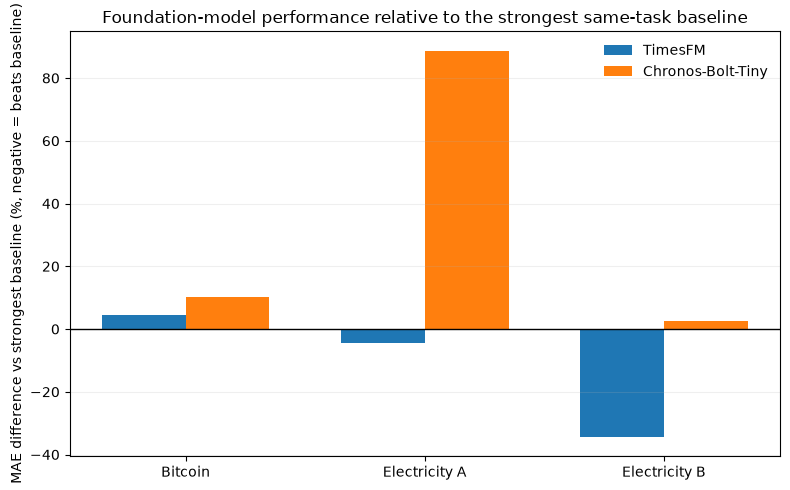

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
tasks_plot = baseline_relative.apply(lambda r: r.Domain if r.Domain == "Bitcoin" else ("Electricity " + r.Protocol.split(":")[0].strip()[-1]), axis=1)
plot_df = baseline_relative.assign(Task=tasks_plot).pivot(index="Task", columns="Model", values="Relative_MAE_Difference_Percent")
plot_df = plot_df.reindex(TASKS)
x = np.arange(len(TASKS)); width = 0.35
ax.bar(x - width / 2, plot_df["TimesFM"], width, label="TimesFM")
ax.bar(x + width / 2, plot_df["Chronos-Bolt-Tiny"], width, label="Chronos-Bolt-Tiny")
ax.axhline(0, color="black", lw=1)
ax.set_xticks(x, TASKS)
ax.set_ylabel("MAE difference vs strongest baseline (%, negative = beats baseline)")
ax.set_title("Foundation-model performance relative to the strongest same-task baseline")
ax.legend(frameon=False)
ax.grid(alpha=0.2, axis="y")
plt.tight_layout()
plt.show()

## 5.4 Foundation Model Performance

In [13]:
foundation_ranks = comparison[comparison.Model.isin(["TimesFM", "Chronos-Bolt-Tiny"])][
    ["Domain", "Protocol", "Model", "Within_Domain_Rank"]
].pivot(index=["Domain", "Protocol"], columns="Model", values="Within_Domain_Rank")
foundation_ranks["Better Point Forecaster"] = np.where(
    foundation_ranks["TimesFM"] < foundation_ranks["Chronos-Bolt-Tiny"], "TimesFM",
    np.where(foundation_ranks["TimesFM"] > foundation_ranks["Chronos-Bolt-Tiny"], "Chronos-Bolt-Tiny", "Tie"))
display(foundation_ranks)

Model                                               Chronos-Bolt-Tiny  \
Domain      Protocol                                                    
Bitcoin     Rolling one-step daily                                  7   
Electricity Protocol A: rolling one-step 30-minute                  5   
            Protocol B: 48-step day-ahead                           3   

Model                                               TimesFM  \
Domain      Protocol                                          
Bitcoin     Rolling one-step daily                        6   
Electricity Protocol A: rolling one-step 30-minute        1   
            Protocol B: 48-step day-ahead                 1   

Model                                              Better Point Forecaster  
Domain      Protocol                                                        
Bitcoin     Rolling one-step daily                                 TimesFM  
Electricity Protocol A: rolling one-step 30-minute                 TimesFM  
            Protocol B: 48-step day-ahead                          TimesFM

# 6. Rank Stability Across Domain and Horizon

## 6.1 Comparable-Family Rank Table

In [14]:
rank_table = rank_stability[[
    "Model_Family", "Bitcoin_Rank", "Electricity_Protocol_A_Rank", "Electricity_Protocol_B_Rank",
    "Mean_Rank", "Rank_Std", "Best_Rank", "Worst_Rank",
]].copy()
rank_table["Bitcoin (of N)"] = rank_table.Bitcoin_Rank.astype(str) + " / " + str(ROSTER_SIZE["Bitcoin"])
rank_table["Electricity A (of N)"] = rank_table.Electricity_Protocol_A_Rank.astype(str) + " / " + str(ROSTER_SIZE["Electricity A"])
rank_table["Electricity B (of N)"] = rank_table.Electricity_Protocol_B_Rank.astype(str) + " / " + str(ROSTER_SIZE["Electricity B"])
display(rank_table[["Model_Family", "Bitcoin (of N)", "Electricity A (of N)", "Electricity B (of N)", "Mean_Rank", "Rank_Std"]])

,Model_Family,Bitcoin (of N),Electricity A (of N),Electricity B (of N),Mean_Rank,Rank_Std
0,ARIMA-family (best),3 / 10,2 / 13,2 / 13,2.333333,0.577350
1,TimesFM,6 / 10,1 / 13,1 / 13,2.666667,2.886751
2,Chronos-Bolt-Tiny,7 / 10,5 / 13,3 / 13,5.000000,2.000000
3,LSTM-family,5 / 10,7 / 13,5 / 13,5.666667,1.154701
4,Naive,1 / 10,6 / 13,11 / 13,6.000000,5.000000
5,Holt-Winters,4 / 10,12 / 13,8 / 13,8.000000,4.000000
6,Simple Exponential Smoothing,2 / 10,13 / 13,10 / 13,8.333333,5.686241
7,Prophet,10 / 10,10 / 13,7 / 13,9.000000,1.732051


## 6.2 Normalized Rank

$$\text{NormalizedRank} = \frac{\text{Rank} - 1}{N - 1}$$

0 = best, 1 = worst within that task's own roster. This is a derived descriptive transformation
that makes a rank of 6-of-10 (Bitcoin) visually comparable to a rank of 8-of-13 (Electricity) --
it is not a new metric of forecasting quality.

In [15]:
norm_rank = rank_stability[["Model_Family"]].copy()
norm_rank["Bitcoin"] = rank_stability.Bitcoin_Rank.apply(lambda r: normalized_rank(r, ROSTER_SIZE["Bitcoin"]))
norm_rank["Electricity A"] = rank_stability.Electricity_Protocol_A_Rank.apply(lambda r: normalized_rank(r, ROSTER_SIZE["Electricity A"]))
norm_rank["Electricity B"] = rank_stability.Electricity_Protocol_B_Rank.apply(lambda r: normalized_rank(r, ROSTER_SIZE["Electricity B"]))
norm_rank["Rank Range"] = norm_rank[["Bitcoin", "Electricity A", "Electricity B"]].max(axis=1) - norm_rank[["Bitcoin", "Electricity A", "Electricity B"]].min(axis=1)
norm_rank = norm_rank.sort_values("Rank Range")
display(norm_rank.round(3))

,Model_Family,Bitcoin,Electricity A,Electricity B,Rank Range
0,ARIMA-family (best),0.222,0.083,0.083,0.139
3,LSTM-family,0.444,0.500,0.333,0.167
2,Chronos-Bolt-Tiny,0.667,0.333,0.167,0.500
7,Prophet,1.000,0.750,0.500,0.500
1,TimesFM,0.556,0.000,0.000,0.556
5,Holt-Winters,0.333,0.917,0.583,0.583
4,Naive,0.000,0.417,0.833,0.833
6,Simple Exponential Smoothing,0.111,1.000,0.750,0.889


## 6.3 Rank-Stability Visualization

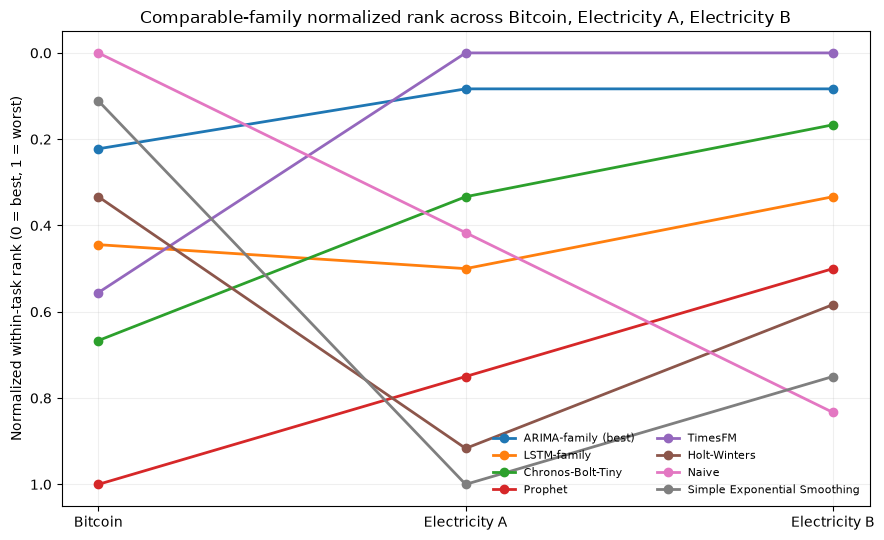

In [16]:
fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(3)
for _, row in norm_rank.iterrows():
    ax.plot(x, [row["Bitcoin"], row["Electricity A"], row["Electricity B"]], marker="o", lw=2, label=row.Model_Family)
ax.set_xticks(x, TASKS)
ax.invert_yaxis()
ax.set_ylabel("Normalized within-task rank (0 = best, 1 = worst)")
ax.set_title("Comparable-family normalized rank across Bitcoin, Electricity A, Electricity B")
ax.legend(frameon=False, fontsize=8, ncol=2)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

All 8 comparable families are shown; there is no missing family in this view (Section 4.2 lists
the models that have no cross-domain counterpart and are therefore excluded from this comparison
by design, not by omission).

## 6.4 Largest Rank Movers

In [17]:
movers = norm_rank.copy()
movers["Best Task Rank"] = rank_stability.set_index("Model_Family").loc[movers.Model_Family, "Best_Rank"].values
movers["Worst Task Rank"] = rank_stability.set_index("Model_Family").loc[movers.Model_Family, "Worst_Rank"].values
movers = movers.sort_values("Rank Range", ascending=False)[["Model_Family", "Best Task Rank", "Worst Task Rank", "Rank Range"]]
movers = movers.rename(columns={"Rank Range": "Normalized Rank Range"})
display(movers.round(3))
display(Markdown(
    "**Largest shift:** %s (normalized rank range %.3f). **Most stable:** %s (normalized rank range %.3f)."
    % (movers.iloc[0].Model_Family, movers.iloc[0]["Normalized Rank Range"], movers.iloc[-1].Model_Family, movers.iloc[-1]["Normalized Rank Range"])
))

,Model_Family,Best Task Rank,Worst Task Rank,Normalized Rank Range
6,Simple Exponential Smoothing,2,13,0.889
4,Naive,1,11,0.833
5,Holt-Winters,4,12,0.583
1,TimesFM,1,6,0.556
2,Chronos-Bolt-Tiny,3,7,0.500
7,Prophet,7,10,0.500
3,LSTM-family,5,7,0.167
0,ARIMA-family (best),2,3,0.139


**Largest shift:** Simple Exponential Smoothing (normalized rank range 0.889). **Most stable:** ARIMA-family (best) (normalized rank range 0.139).

# 7. Regime-Conditional Robustness Across Tasks

Regimes are domain-specific by construction (Bitcoin's are return/volatility-based; Electricity's
are demand/peak-event-based). Bitcoin's "High Volatility" regime is not numerically compared with
Electricity's "High Demand" regime as if they were the same stress condition -- instead, each
model's **within-domain relative robustness rank** is compared, which is a domain-relative
statement, not a claim of equivalent stress.

## 7.1 Comparable Robustness Evidence

In [18]:
def full_roster_rank(df, model_col, score_col):
    s = df.set_index(model_col)[score_col]
    return s.rank(ascending=False, method="min")

bitcoin_robustness_rank = full_roster_rank(bitcoin_components, "Model", "Regime-Conditional Robustness")
elec_a_robustness_rank = full_roster_rank(electricity_trust_a, "Model", "Relative Robustness Score")
elec_b_robustness_rank = full_roster_rank(electricity_trust_b, "Model", "Relative Robustness Score")

def lookup_rank(rank_series, model_name):
    key = norm(model_name)
    for idx, val in rank_series.items():
        if norm(idx) == key:
            return val
    return np.nan

robustness_families = families_display.copy()
robustness_families["Bitcoin Robustness Rank"] = robustness_families.Bitcoin_Representative.apply(lambda m: lookup_rank(bitcoin_robustness_rank, m))
robustness_families["Electricity A Robustness Rank"] = robustness_families.Electricity_Representative.apply(lambda m: lookup_rank(elec_a_robustness_rank, m))
robustness_families["Electricity B Robustness Rank"] = robustness_families.Electricity_Representative.apply(lambda m: lookup_rank(elec_b_robustness_rank, m))
robustness_view = robustness_families[["Model_Family", "Bitcoin Robustness Rank", "Electricity A Robustness Rank", "Electricity B Robustness Rank"]]
display(robustness_view)

,Model_Family,Bitcoin Robustness Rank,Electricity A Robustness Rank,Electricity B Robustness Rank
0,Naive,3.0,5.0,7.0
1,Chronos-Bolt-Tiny,7.0,7.0,4.0
2,TimesFM,5.0,1.0,1.0
3,ARIMA-family (best),1.0,2.0,2.0
4,Prophet,10.0,11.0,10.0
5,Simple Exponential Smoothing,2.0,10.0,8.0
6,Holt-Winters,4.0,13.0,13.0
7,LSTM-family,6.0,6.0,5.0


## 7.2 Robustness Rank Stability

In [19]:
norm_robustness = robustness_view[["Model_Family"]].copy()
norm_robustness["Bitcoin"] = robustness_view["Bitcoin Robustness Rank"].apply(lambda r: normalized_rank(r, ROSTER_SIZE["Bitcoin"]))
norm_robustness["Electricity A"] = robustness_view["Electricity A Robustness Rank"].apply(lambda r: normalized_rank(r, ROSTER_SIZE["Electricity A"]))
norm_robustness["Electricity B"] = robustness_view["Electricity B Robustness Rank"].apply(lambda r: normalized_rank(r, ROSTER_SIZE["Electricity B"]))
norm_robustness["Rank Range"] = norm_robustness[["Bitcoin", "Electricity A", "Electricity B"]].max(axis=1) - norm_robustness[["Bitcoin", "Electricity A", "Electricity B"]].min(axis=1)
display(norm_robustness.sort_values("Rank Range").round(3))

,Model_Family,Bitcoin,Electricity A,Electricity B,Rank Range
3,ARIMA-family (best),0.000,0.083,0.083,0.083
7,LSTM-family,0.556,0.417,0.333,0.222
4,Prophet,1.000,0.833,0.750,0.250
0,Naive,0.222,0.333,0.500,0.278
1,Chronos-Bolt-Tiny,0.667,0.500,0.250,0.417
2,TimesFM,0.444,0.000,0.000,0.444
5,Simple Exponential Smoothing,0.111,0.750,0.583,0.639
6,Holt-Winters,0.333,1.000,1.000,0.667


## 7.3 Aggregate Accuracy vs Robustness

In [20]:
def accuracy_vs_other(domain, protocol_substr, other_rank_series, other_label):
    sub = comparison[(comparison.Domain == domain) & (comparison.Protocol.str.contains(protocol_substr))].copy()
    sub["Family"] = sub.Model.map(family_of)
    sub[other_label] = sub.Model.apply(lambda m: lookup_rank(other_rank_series, m))
    sub = sub[sub.Family != "No cross-domain family"]
    sub["Difference"] = sub[other_label] - sub.Within_Domain_Rank
    return sub[["Model", "Family", "Within_Domain_Rank", other_label, "Difference"]].rename(
        columns={"Within_Domain_Rank": "Accuracy Rank"}).sort_values("Accuracy Rank")

acc_vs_rob_bitcoin = accuracy_vs_other("Bitcoin", "", bitcoin_robustness_rank, "Robustness Rank")
acc_vs_rob_a = accuracy_vs_other("Electricity", "A", elec_a_robustness_rank, "Robustness Rank")
acc_vs_rob_b = accuracy_vs_other("Electricity", "B", elec_b_robustness_rank, "Robustness Rank")

display(Markdown("**Bitcoin: accuracy rank vs robustness rank (comparable families)**")); display(acc_vs_rob_bitcoin)
display(Markdown("**Electricity A: accuracy rank vs robustness rank (comparable families)**")); display(acc_vs_rob_a)
display(Markdown("**Electricity B: accuracy rank vs robustness rank (comparable families)**")); display(acc_vs_rob_b)

max_gap = pd.concat([acc_vs_rob_bitcoin, acc_vs_rob_a, acc_vs_rob_b]).assign(AbsDiff=lambda d: d.Difference.abs()).nlargest(1, "AbsDiff")
display(Markdown(
    "Largest accuracy-vs-robustness gap among comparable families: **%s** (accuracy rank %d, robustness rank %d)."
    % (max_gap.Model.iloc[0], int(max_gap["Accuracy Rank"].iloc[0]), int(max_gap["Robustness Rank"].iloc[0]))
))

**Bitcoin: accuracy rank vs robustness rank (comparable families)**

,Model,Family,Accuracy Rank,Robustness Rank,Difference
0,Naive,Naive,1,3.0,2.0
1,Simple Exponential Smoothing — Rolling One-Step,Simple Exponential Smoothing,2,2.0,0.0
3,ARIMA Rolling One-Step,ARIMA-family (best),3,1.0,-2.0
2,Additive-Trend Exponential Smoothing,Holt-Winters,4,4.0,0.0
6,Persistence-Enhanced Log-Return LSTM,LSTM-family,5,6.0,1.0
9,TimesFM,TimesFM,6,5.0,-1.0
8,Chronos-Bolt-Tiny,Chronos-Bolt-Tiny,7,7.0,0.0
5,Prophet — 30-Day Periodic Refit,Prophet,10,10.0,0.0


**Electricity A: accuracy rank vs robustness rank (comparable families)**

,Model,Family,Accuracy Rank,Robustness Rank,Difference
22,TimesFM,TimesFM,1,1.0,0.0
15,SARIMA,ARIMA-family (best),2,2.0,0.0
21,Chronos-Bolt-Tiny,Chronos-Bolt-Tiny,5,7.0,2.0
10,Naive,Naive,6,5.0,-1.0
20,LSTM,LSTM-family,7,6.0,-1.0
16,Prophet,Prophet,10,11.0,1.0
18,Holt-Winters,Holt-Winters,12,13.0,1.0
17,Simple Exponential Smoothing,Simple Exponential Smoothing,13,10.0,-3.0


**Electricity B: accuracy rank vs robustness rank (comparable families)**

,Model,Family,Accuracy Rank,Robustness Rank,Difference
35,TimesFM,TimesFM,1,1.0,0.0
28,SARIMA,ARIMA-family (best),2,2.0,0.0
34,Chronos-Bolt-Tiny,Chronos-Bolt-Tiny,3,4.0,1.0
33,LSTM,LSTM-family,5,5.0,0.0
29,Prophet,Prophet,7,10.0,3.0
31,Holt-Winters,Holt-Winters,8,13.0,5.0
30,Simple Exponential Smoothing,Simple Exponential Smoothing,10,8.0,-2.0
23,Naive,Naive,11,7.0,-4.0


Largest accuracy-vs-robustness gap among comparable families: **Holt-Winters** (accuracy rank 8, robustness rank 13).

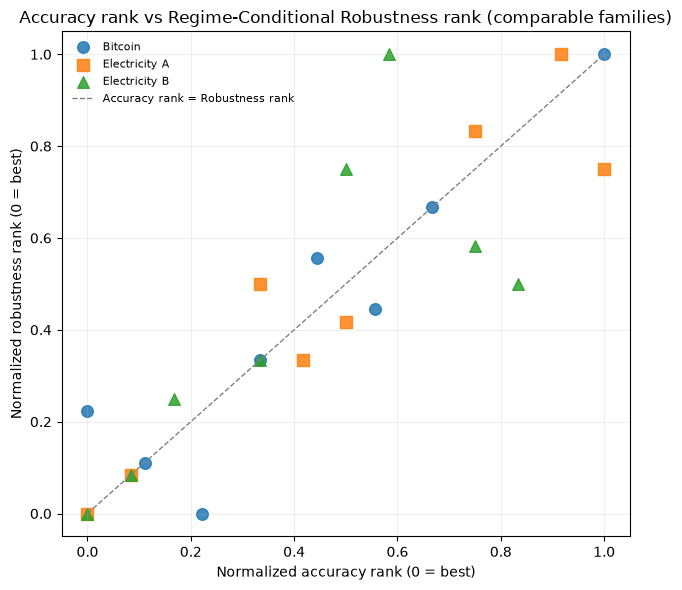

In [21]:
fig, ax = plt.subplots(figsize=(6.5, 6))
markers = {"Bitcoin": "o", "Electricity A": "s", "Electricity B": "^"}
for task, sub, roster in [("Bitcoin", acc_vs_rob_bitcoin, ROSTER_SIZE["Bitcoin"]),
                           ("Electricity A", acc_vs_rob_a, ROSTER_SIZE["Electricity A"]),
                           ("Electricity B", acc_vs_rob_b, ROSTER_SIZE["Electricity B"])]:
    ax.scatter(sub["Accuracy Rank"].apply(lambda r: normalized_rank(r, roster)),
               sub["Robustness Rank"].apply(lambda r: normalized_rank(r, roster)),
               marker=markers[task], s=70, label=task, alpha=0.85)
lims = [0, 1]
ax.plot(lims, lims, ls="--", color="gray", lw=1, label="Accuracy rank = Robustness rank")
ax.set_xlabel("Normalized accuracy rank (0 = best)")
ax.set_ylabel("Normalized robustness rank (0 = best)")
ax.set_title("Accuracy rank vs Regime-Conditional Robustness rank (comparable families)")
ax.legend(frameon=False, fontsize=8)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# 8. Temporal Stability Across Tasks

Public-facing terminology uses **Temporal Stability** throughout this section, defined as error
consistency across contiguous Earlier/Middle/Later test segments. The underlying Electricity
artifact column is still named `Relative_Generalisation_Score` for hash stability with the frozen
per-protocol trust-score files; this notebook applies a display alias and does not rename the
source column. Temporal Stability does **not** establish geographic, cross-dataset, causal, or
broad out-of-distribution generalisation -- it is a within-series, contiguous-segment consistency
check only.

## 8.1 Comparable Temporal Evidence

In [22]:
bitcoin_stability_rank = full_roster_rank(bitcoin_components, "Model", "Temporal Stability")
elec_a_stability_rank = full_roster_rank(electricity_trust_a, "Model", "Relative Generalisation Score")
elec_b_stability_rank = full_roster_rank(electricity_trust_b, "Model", "Relative Generalisation Score")

stability_families = families_display.copy()
stability_families["Bitcoin Temporal Stability Rank"] = stability_families.Bitcoin_Representative.apply(lambda m: lookup_rank(bitcoin_stability_rank, m))
stability_families["Electricity A Temporal Stability Rank"] = stability_families.Electricity_Representative.apply(lambda m: lookup_rank(elec_a_stability_rank, m))
stability_families["Electricity B Temporal Stability Rank"] = stability_families.Electricity_Representative.apply(lambda m: lookup_rank(elec_b_stability_rank, m))
stability_view = stability_families[["Model_Family", "Bitcoin Temporal Stability Rank", "Electricity A Temporal Stability Rank", "Electricity B Temporal Stability Rank"]]
display(stability_view)

,Model_Family,Bitcoin Temporal Stability Rank,Electricity A Temporal Stability Rank,Electricity B Temporal Stability Rank
0,Naive,1.0,6.0,11.0
1,Chronos-Bolt-Tiny,7.0,5.0,3.0
2,TimesFM,6.0,1.0,1.0
3,ARIMA-family (best),4.0,2.0,2.0
4,Prophet,10.0,11.0,7.0
5,Simple Exponential Smoothing,2.0,13.0,10.0
6,Holt-Winters,3.0,12.0,8.0
7,LSTM-family,5.0,7.0,5.0


## 8.2 Accuracy vs Temporal Stability

In [23]:
acc_vs_stab_bitcoin = accuracy_vs_other("Bitcoin", "", bitcoin_stability_rank, "Temporal Stability Rank")
acc_vs_stab_a = accuracy_vs_other("Electricity", "A", elec_a_stability_rank, "Temporal Stability Rank")
acc_vs_stab_b = accuracy_vs_other("Electricity", "B", elec_b_stability_rank, "Temporal Stability Rank")

display(Markdown("**Bitcoin: accuracy rank vs Temporal Stability rank**")); display(acc_vs_stab_bitcoin)
display(Markdown("**Electricity A: accuracy rank vs Temporal Stability rank**")); display(acc_vs_stab_a)
display(Markdown("**Electricity B: accuracy rank vs Temporal Stability rank**")); display(acc_vs_stab_b)

**Bitcoin: accuracy rank vs Temporal Stability rank**

,Model,Family,Accuracy Rank,Temporal Stability Rank,Difference
0,Naive,Naive,1,1.0,0.0
1,Simple Exponential Smoothing — Rolling One-Step,Simple Exponential Smoothing,2,2.0,0.0
3,ARIMA Rolling One-Step,ARIMA-family (best),3,4.0,1.0
2,Additive-Trend Exponential Smoothing,Holt-Winters,4,3.0,-1.0
6,Persistence-Enhanced Log-Return LSTM,LSTM-family,5,5.0,0.0
9,TimesFM,TimesFM,6,6.0,0.0
8,Chronos-Bolt-Tiny,Chronos-Bolt-Tiny,7,7.0,0.0
5,Prophet — 30-Day Periodic Refit,Prophet,10,10.0,0.0


**Electricity A: accuracy rank vs Temporal Stability rank**

,Model,Family,Accuracy Rank,Temporal Stability Rank,Difference
22,TimesFM,TimesFM,1,1.0,0.0
15,SARIMA,ARIMA-family (best),2,2.0,0.0
21,Chronos-Bolt-Tiny,Chronos-Bolt-Tiny,5,5.0,0.0
10,Naive,Naive,6,6.0,0.0
20,LSTM,LSTM-family,7,7.0,0.0
16,Prophet,Prophet,10,11.0,1.0
18,Holt-Winters,Holt-Winters,12,12.0,0.0
17,Simple Exponential Smoothing,Simple Exponential Smoothing,13,13.0,0.0


**Electricity B: accuracy rank vs Temporal Stability rank**

,Model,Family,Accuracy Rank,Temporal Stability Rank,Difference
35,TimesFM,TimesFM,1,1.0,0.0
28,SARIMA,ARIMA-family (best),2,2.0,0.0
34,Chronos-Bolt-Tiny,Chronos-Bolt-Tiny,3,3.0,0.0
33,LSTM,LSTM-family,5,5.0,0.0
29,Prophet,Prophet,7,7.0,0.0
31,Holt-Winters,Holt-Winters,8,8.0,0.0
30,Simple Exponential Smoothing,Simple Exponential Smoothing,10,10.0,0.0
23,Naive,Naive,11,11.0,0.0


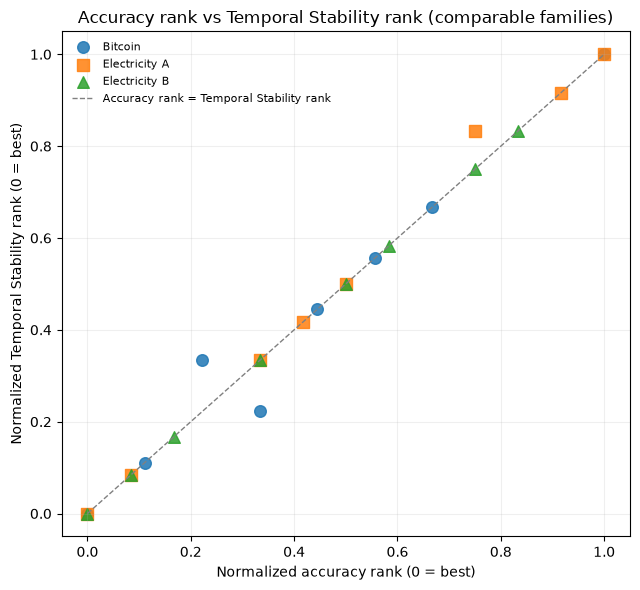

In [24]:
fig, ax = plt.subplots(figsize=(6.5, 6))
for task, sub, roster in [("Bitcoin", acc_vs_stab_bitcoin, ROSTER_SIZE["Bitcoin"]),
                           ("Electricity A", acc_vs_stab_a, ROSTER_SIZE["Electricity A"]),
                           ("Electricity B", acc_vs_stab_b, ROSTER_SIZE["Electricity B"])]:
    ax.scatter(sub["Accuracy Rank"].apply(lambda r: normalized_rank(r, roster)),
               sub["Temporal Stability Rank"].apply(lambda r: normalized_rank(r, roster)),
               marker=markers[task], s=70, label=task, alpha=0.85)
ax.plot(lims, lims, ls="--", color="gray", lw=1, label="Accuracy rank = Temporal Stability rank")
ax.set_xlabel("Normalized accuracy rank (0 = best)")
ax.set_ylabel("Normalized Temporal Stability rank (0 = best)")
ax.set_title("Accuracy rank vs Temporal Stability rank (comparable families)")
ax.legend(frameon=False, fontsize=8)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 8.3 Cross-Task Temporal Rank Stability

In [25]:
norm_stability = stability_view[["Model_Family"]].copy()
norm_stability["Bitcoin"] = stability_view["Bitcoin Temporal Stability Rank"].apply(lambda r: normalized_rank(r, ROSTER_SIZE["Bitcoin"]))
norm_stability["Electricity A"] = stability_view["Electricity A Temporal Stability Rank"].apply(lambda r: normalized_rank(r, ROSTER_SIZE["Electricity A"]))
norm_stability["Electricity B"] = stability_view["Electricity B Temporal Stability Rank"].apply(lambda r: normalized_rank(r, ROSTER_SIZE["Electricity B"]))
norm_stability["Rank Range"] = norm_stability[["Bitcoin", "Electricity A", "Electricity B"]].max(axis=1) - norm_stability[["Bitcoin", "Electricity A", "Electricity B"]].min(axis=1)
display(norm_stability.sort_values("Rank Range").round(3))

,Model_Family,Bitcoin,Electricity A,Electricity B,Rank Range
7,LSTM-family,0.444,0.500,0.333,0.167
3,ARIMA-family (best),0.333,0.083,0.083,0.250
4,Prophet,1.000,0.833,0.500,0.500
1,Chronos-Bolt-Tiny,0.667,0.333,0.167,0.500
2,TimesFM,0.556,0.000,0.000,0.556
6,Holt-Winters,0.222,0.917,0.583,0.694
0,Naive,0.000,0.417,0.833,0.833
5,Simple Exponential Smoothing,0.111,1.000,0.750,0.889


# 9. Uncertainty Calibration Across Tasks

## 9.1 Evidence Types

In [26]:
bitcoin_vector_preserved = len(bitcoin_uncertainty) == n_bitcoin_test
electricity_notes = electricity_uncertainty[electricity_uncertainty.Available == True]["Notes"].tolist()
electricity_vector_preserved = not any("vectors not saved" in n for n in electricity_notes)

evidence_types = uncertainty_cmp[["Domain", "Protocol", "Model", "Calibration_Type", "Nominal_Coverage"]].copy()
evidence_types["Exact Interval Vector Preserved?"] = np.where(
    evidence_types.Domain == "Bitcoin", bitcoin_vector_preserved, electricity_vector_preserved)
display(evidence_types)

,Domain,Protocol,Model,Calibration_Type,Nominal_Coverage,Exact Interval Vector Preserved?
0,Bitcoin,Rolling one-step daily,Chronos-Bolt-Tiny,Native,0.8,True
1,Bitcoin,Rolling one-step daily,Chronos-Bolt-Tiny,Calibrated,0.8,True
2,Bitcoin,Rolling one-step daily,TimesFM,Native,0.8,True
3,Bitcoin,Rolling one-step daily,TimesFM,Calibrated,0.8,True
4,Electricity,Protocol A: rolling one-step 30-minute,Chronos-Bolt-Tiny,Native,0.8,False
5,Electricity,Protocol A: rolling one-step 30-minute,TimesFM,Native,0.8,False
6,Electricity,Protocol B: 48-step day-ahead,Chronos-Bolt-Tiny,Native,0.8,False
7,Electricity,Protocol B: 48-step day-ahead,TimesFM,Native,0.8,False


Bitcoin preserves the full per-day interval vector (native and post-hoc calibrated) for both
foundation models; Electricity preserves the aggregate 80% coverage result only, as explicitly
recorded in its own uncertainty artifact -- this is reported as absent, not fabricated.

## 9.2 Native 80% Calibration Comparison

In [27]:
native = uncertainty_cmp[uncertainty_cmp.Calibration_Type == "Native"].copy()
native["Task"] = native.Domain + np.where(native.Protocol.str.contains("Protocol A"), " A",
                    np.where(native.Protocol.str.contains("Protocol B"), " B", ""))
native["Signed_Coverage_Error"] = native.Empirical_Coverage - native.Nominal_Coverage
native["Absolute_Coverage_Error"] = native.Signed_Coverage_Error.abs()
native_view = native[["Task", "Model", "Nominal_Coverage", "Empirical_Coverage", "Signed_Coverage_Error", "Absolute_Coverage_Error"]] \
    .sort_values(["Task", "Model"])
display(native_view)

,Task,Model,Nominal_Coverage,Empirical_Coverage,Signed_Coverage_Error,Absolute_Coverage_Error
0,Bitcoin,Chronos-Bolt-Tiny,0.8,0.845429,0.045429,0.045429
2,Bitcoin,TimesFM,0.8,0.330820,-0.469180,0.469180
4,Electricity A,Chronos-Bolt-Tiny,0.8,0.911231,0.111231,0.111231
5,Electricity A,TimesFM,0.8,0.336495,-0.463505,0.463505
6,Electricity B,Chronos-Bolt-Tiny,0.8,0.676239,-0.123761,0.123761
7,Electricity B,TimesFM,0.8,0.245604,-0.554396,0.554396


## 9.3 Calibration Visualization

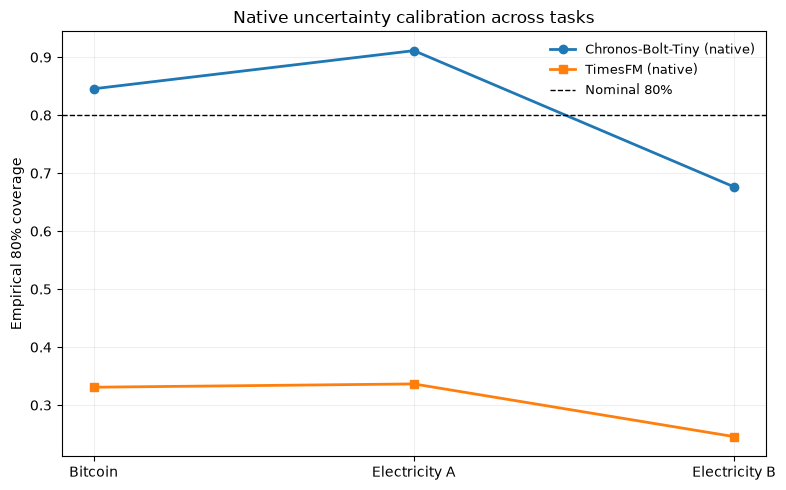

In [28]:
fig, ax = plt.subplots(figsize=(8, 5))
task_order = native_view.Task.unique().tolist()
for model, marker in [("Chronos-Bolt-Tiny", "o"), ("TimesFM", "s")]:
    sub = native_view[native_view.Model == model].set_index("Task").reindex(task_order)
    ax.plot(task_order, sub.Empirical_Coverage, marker=marker, lw=2, label=model + " (native)")
ax.axhline(0.80, color="black", ls="--", lw=1, label="Nominal 80%")
ax.set_ylabel("Empirical 80% coverage")
ax.set_title("Native uncertainty calibration across tasks")
ax.legend(frameon=False, fontsize=9)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 9.4 Accuracy vs Calibration

In [29]:
# task-specific lookup avoids domain/protocol ambiguity in a plain merge
rows = []
for _, r in native_view.iterrows():
    dom = "Bitcoin" if r.Task == "Bitcoin" else "Electricity"
    proto_sub = "" if r.Task == "Bitcoin" else r.Task.split()[-1]
    match = comparison[(comparison.Domain == dom) & (comparison.Protocol.str.contains(proto_sub)) & (comparison.Model == r.Model)]
    rows.append({"Task": r.Task, "Model": r.Model, "Point Rank": int(match.Within_Domain_Rank.iloc[0]),
                 "Abs Coverage Error": r.Absolute_Coverage_Error})
acc_cal_table = pd.DataFrame(rows)
pref = acc_cal_table.pivot(index="Task", columns="Model", values="Abs Coverage Error")
pref["Calibration Preference"] = np.where(pref["Chronos-Bolt-Tiny"] < pref["TimesFM"], "Chronos-Bolt-Tiny", "TimesFM")
display(acc_cal_table.sort_values(["Task", "Point Rank"]))
display(pref)

,Task,Model,Point Rank,Abs Coverage Error
1,Bitcoin,TimesFM,6,0.469180
0,Bitcoin,Chronos-Bolt-Tiny,7,0.045429
3,Electricity A,TimesFM,1,0.463505
2,Electricity A,Chronos-Bolt-Tiny,5,0.111231
5,Electricity B,TimesFM,1,0.554396
4,Electricity B,Chronos-Bolt-Tiny,3,0.123761


Model,Chronos-Bolt-Tiny,TimesFM,Calibration Preference
Task,,,
Bitcoin,0.045429,0.469180,Chronos-Bolt-Tiny
Electricity A,0.111231,0.463505,Chronos-Bolt-Tiny
Electricity B,0.123761,0.554396,Chronos-Bolt-Tiny


Better point-forecast rank does not imply better calibration: TimesFM leads point accuracy in both
Electricity protocols yet has the larger absolute coverage error of the two foundation models in
every task shown here.

## 9.5 Calibrated Bitcoin Evidence

In [30]:
calibrated = uncertainty_cmp[uncertainty_cmp.Calibration_Type == "Calibrated"].copy()
calibrated["Signed_Coverage_Error"] = calibrated.Empirical_Coverage - calibrated.Nominal_Coverage
display(calibrated[["Domain", "Model", "Nominal_Coverage", "Empirical_Coverage", "Signed_Coverage_Error"]])

,Domain,Model,Nominal_Coverage,Empirical_Coverage,Signed_Coverage_Error
1,Bitcoin,Chronos-Bolt-Tiny,0.8,0.815269,0.015269
3,Bitcoin,TimesFM,0.8,0.556079,-0.243921


Post-hoc calibrated Bitcoin evidence is useful within Bitcoin (it shows how training-only conformal
adjustment moves each foundation model's coverage relative to its own native evidence) but has no
matched Electricity calibration procedure, so it is not part of the primary cross-task native
calibration comparison in Section 9.2-9.4.

# 10. Multidimensional Trustworthiness Evidence

Component evidence is presented before the composite score, consistent with the domain
notebooks' own framework: the composite is a secondary, researcher-defined, comparison-set-relative
summary, not the primary trustworthiness evidence.

## 10.1 Component Comparison

In [31]:
component_display = trust_cmp.rename(columns={
    "Relative_Accuracy_Score": "Accuracy Score",
    "Relative_Robustness_Score": "Robustness Score",
    "Relative_Generalisation_Score": "Temporal Stability Score",
    "Uncertainty_Score": "Uncertainty Score",
    "Explainability_Score": "Explainability Score",
})[["Model_Family", "Domain", "Protocol", "Model", "Accuracy Score", "Robustness Score",
    "Temporal Stability Score", "Uncertainty Score", "Explainability Score"]]
display(component_display.sort_values(["Domain", "Protocol", "Model_Family"]))

,Model_Family,Domain,Protocol,Model,Accuracy Score,Robustness Score,Temporal Stability Score,Uncertainty Score,Explainability Score
9,ARIMA-family (best),Bitcoin,Rolling one-step daily,ARIMA Rolling One-Step,99.320684,99.965748,98.988513,86.615087,90.0
3,Chronos-Bolt-Tiny,Bitcoin,Rolling one-step daily,Chronos-Bolt-Tiny,92.959750,95.289892,93.750212,93.789195,69.0
18,Holt-Winters,Bitcoin,Rolling one-step daily,Additive-Trend Exponential Smoothing,99.034173,99.431127,99.193747,86.615782,92.0
21,LSTM-family,Bitcoin,Rolling one-step daily,Persistence-Enhanced Log-Return LSTM,98.539868,98.650580,98.407655,0.000000,57.0
0,Naive,Bitcoin,Rolling one-step daily,Naive,100.000000,99.848118,100.000000,86.227706,99.0
12,Prophet,Bitcoin,Rolling one-step daily,Prophet — 30-Day Periodic Refit,17.193180,25.000646,17.036188,0.000000,82.0
15,Simple Exponential Smoothing,Bitcoin,Rolling one-step daily,Simple Exponential Smoothing — Rolling One-Step,99.886479,100.000000,99.913332,87.091579,94.6
6,TimesFM,Bitcoin,Rolling one-step daily,TimesFM,96.332263,98.000672,95.992177,78.047125,63.0
10,ARIMA-family (best),Electricity,Protocol A: rolling one-step 30-minute,SARIMA,95.663768,83.677341,96.701207,NaN,76.6
4,Chronos-Bolt-Tiny,Electricity,Protocol A: rolling one-step 30-minute,Chronos-Bolt-Tiny,50.687510,33.528650,52.022174,65.948742,63.0


## 10.2 Evidence Availability

In [32]:
avail = trust_cmp.copy()
avail["Missing"] = np.where(avail.Uncertainty_Score.isna(), "Uncertainty Score", "None")
avail_pivot = avail.pivot_table(index="Model_Family", columns="Domain", values="Missing", aggfunc=lambda s: ", ".join(sorted(set(s))))
# split Electricity by protocol explicitly
avail["Task"] = np.where(avail.Domain == "Bitcoin", "Bitcoin",
                  np.where(avail.Protocol.str.contains("A"), "Electricity A", "Electricity B"))
avail_table = avail.pivot(index="Model_Family", columns="Task", values="Missing")[["Bitcoin", "Electricity A", "Electricity B"]]
avail_table = avail_table.rename(columns={
    "Bitcoin": "Bitcoin Missing Dimensions", "Electricity A": "Electricity A Missing Dimensions", "Electricity B": "Electricity B Missing Dimensions"})
display(avail_table)

Task,Bitcoin Missing Dimensions,Electricity A Missing Dimensions,Electricity B Missing Dimensions
Model_Family,,,
ARIMA-family (best),None,Uncertainty Score,Uncertainty Score
Chronos-Bolt-Tiny,None,None,None
Holt-Winters,None,Uncertainty Score,Uncertainty Score
LSTM-family,None,Uncertainty Score,Uncertainty Score
Naive,None,Uncertainty Score,Uncertainty Score
Prophet,None,Uncertainty Score,Uncertainty Score
Simple Exponential Smoothing,None,Uncertainty Score,Uncertainty Score
TimesFM,None,None,None


## 10.3 Composite Results

In [33]:
bitcoin_penalised_rank = full_roster_rank(bitcoin_components, "Model", "Exploratory Composite \u2014 Missing Evidence Penalised")
elec_a_penalised_rank = full_roster_rank(electricity_trust_a, "Model", "Overall Trust Score - Missing Evidence Penalised")
elec_b_penalised_rank = full_roster_rank(electricity_trust_b, "Model", "Overall Trust Score - Missing Evidence Penalised")

composite = trust_cmp[["Model_Family", "Domain", "Protocol", "Model", "Penalised_Trust_Score", "Evidence_Available_Trust_Score"]].copy()
composite["Task"] = np.where(composite.Domain == "Bitcoin", "Bitcoin",
                     np.where(composite.Protocol.str.contains("A"), "Electricity A", "Electricity B"))

def composite_rank_lookup(task, model):
    if task == "Bitcoin":
        return lookup_rank(bitcoin_penalised_rank, model)
    elif task == "Electricity A":
        return lookup_rank(elec_a_penalised_rank, model)
    else:
        return lookup_rank(elec_b_penalised_rank, model)

composite["Penalised Rank (full roster)"] = composite.apply(lambda r: composite_rank_lookup(r.Task, r.Model), axis=1)
composite["Normalized Penalised Rank"] = composite.apply(lambda r: normalized_rank(r["Penalised Rank (full roster)"], ROSTER_SIZE[r.Task]), axis=1)
display(composite[["Model_Family", "Task", "Penalised_Trust_Score", "Evidence_Available_Trust_Score",
                    "Penalised Rank (full roster)", "Normalized Penalised Rank"]].sort_values(["Task", "Penalised Rank (full roster)"]))

,Model_Family,Task,Penalised_Trust_Score,Evidence_Available_Trust_Score,Penalised Rank (full roster),Normalized Penalised Rank
0,Naive,Bitcoin,97.803780,97.803780,1.0,0.000000
15,Simple Exponential Smoothing,Bitcoin,97.466671,97.466671,2.0,0.111111
9,ARIMA-family (best),Bitcoin,96.545355,96.545355,3.0,0.222222
18,Holt-Winters,Bitcoin,96.579302,96.579302,4.0,0.333333
3,Chronos-Bolt-Tiny,Bitcoin,91.312313,91.312313,5.0,0.444444
6,TimesFM,Bitcoin,90.521931,90.521931,6.0,0.555556
21,LSTM-family,Bitcoin,79.600601,93.647766,7.0,0.666667
12,Prophet,Bitcoin,22.624980,26.617624,10.0,1.000000
7,TimesFM,Electricity A,92.033197,92.033197,1.0,0.000000
10,ARIMA-family (best),Electricity A,77.218028,90.844739,2.0,0.083333


Composite results are compared here by **normalized within-task rank**, not by raw Trust Score
magnitude: Bitcoin's roster has 10 models and Electricity's has 13 per protocol, so identical raw
scores do not represent an identical competitive position.

## 10.4 Component vs Composite Disagreement

In [34]:
component_cols = ["Accuracy Score", "Robustness Score", "Temporal Stability Score", "Uncertainty Score", "Explainability Score"]

def weakest_component(row):
    vals = {c: row[c] for c in component_cols if pd.notna(row[c])}
    if not vals:
        return "None available"
    weakest = min(vals, key=vals.get)
    return weakest

disagreement = component_display.copy()
disagreement["Task"] = np.where(disagreement.Domain == "Bitcoin", "Bitcoin",
                        np.where(disagreement.Protocol.str.contains("A"), "Electricity A", "Electricity B"))
disagreement["Largest Component Weakness"] = disagreement.apply(weakest_component, axis=1)
disagreement = disagreement.merge(composite[["Model_Family", "Task", "Penalised Rank (full roster)"]],
                                   on=["Model_Family", "Task"], how="left").rename(columns={"Penalised Rank (full roster)": "Composite Rank"})

accuracy_rank_by_task = pd.concat([
    acc_vs_rob_bitcoin.assign(Task="Bitcoin"),
    acc_vs_rob_a.assign(Task="Electricity A"),
    acc_vs_rob_b.assign(Task="Electricity B"),
])[["Task", "Family", "Accuracy Rank"]].rename(columns={"Family": "Model_Family"})
disagreement = disagreement.merge(accuracy_rank_by_task, on=["Task", "Model_Family"], how="left")

display(disagreement[["Task", "Model", "Accuracy Rank", "Composite Rank", "Largest Component Weakness"]].sort_values(["Task", "Accuracy Rank"]))

,Task,Model,Accuracy Rank,Composite Rank,Largest Component Weakness
0,Bitcoin,Naive,1,1.0,Uncertainty Score
15,Bitcoin,Simple Exponential Smoothing — Rolling One-Step,2,2.0,Uncertainty Score
9,Bitcoin,ARIMA Rolling One-Step,3,3.0,Uncertainty Score
18,Bitcoin,Additive-Trend Exponential Smoothing,4,4.0,Uncertainty Score
21,Bitcoin,Persistence-Enhanced Log-Return LSTM,5,7.0,Uncertainty Score
6,Bitcoin,TimesFM,6,6.0,Explainability Score
3,Bitcoin,Chronos-Bolt-Tiny,7,5.0,Explainability Score
12,Bitcoin,Prophet — 30-Day Periodic Refit,10,10.0,Uncertainty Score
7,Electricity A,TimesFM,1,1.0,Uncertainty Score
10,Electricity A,SARIMA,2,2.0,Explainability Score


### Trustworthiness Evidence Matrix

One consolidated view across every dimension computed so far, at the model-family x task level.
Unavailable uncertainty evidence is shown as a neutral missing marker, never as a numeric zero.

In [35]:
bitcoin_evidence_rank = full_roster_rank(bitcoin_components, "Model", "Exploratory Composite \u2014 Evidence Available")
elec_a_evidence_rank = full_roster_rank(electricity_trust_a, "Model", "Evidence-Available Trust Score")
elec_b_evidence_rank = full_roster_rank(electricity_trust_b, "Model", "Evidence-Available Trust Score")

def evidence_rank_lookup(task, model):
    src = bitcoin_evidence_rank if task == "Bitcoin" else (elec_a_evidence_rank if task == "Electricity A" else elec_b_evidence_rank)
    return lookup_rank(src, model)

composite["Evidence-Available Rank (full roster)"] = composite.apply(lambda r: evidence_rank_lookup(r.Task, r.Model), axis=1)

matrix_parts = []
for task, acc_rob, acc_stab in [("Bitcoin", acc_vs_rob_bitcoin, acc_vs_stab_bitcoin),
                                 ("Electricity A", acc_vs_rob_a, acc_vs_stab_a),
                                 ("Electricity B", acc_vs_rob_b, acc_vs_stab_b)]:
    m = acc_rob[["Family", "Accuracy Rank", "Robustness Rank"]].merge(
        acc_stab[["Family", "Temporal Stability Rank"]], on="Family", how="outer")
    m["Task"] = task
    matrix_parts.append(m)
matrix = pd.concat(matrix_parts, ignore_index=True).rename(columns={"Family": "Model_Family"})

br = baseline_relative.copy()
br["Task"] = br.apply(lambda r: r.Domain if r.Domain == "Bitcoin" else ("Electricity " + r.Protocol.split(":")[0].strip()[-1]), axis=1)
br["Model_Family"] = br.Model.map(family_of)
matrix = matrix.merge(br[["Task", "Model_Family", "Relative_MAE_Difference_Percent"]], on=["Task", "Model_Family"], how="left")

nv = native_view.copy()
nv["Model_Family"] = nv.Model.map(family_of)
matrix = matrix.merge(nv[["Task", "Model_Family", "Absolute_Coverage_Error"]], on=["Task", "Model_Family"], how="left")

comp_avail = component_display.copy()
comp_avail["Task"] = np.where(comp_avail.Domain == "Bitcoin", "Bitcoin", np.where(comp_avail.Protocol.str.contains("A"), "Electricity A", "Electricity B"))
matrix = matrix.merge(comp_avail[["Task", "Model_Family", "Uncertainty Score"]], on=["Task", "Model_Family"], how="left")
matrix["Uncertainty Available?"] = matrix["Uncertainty Score"].notna().map({True: "Yes", False: "No"})
matrix = matrix.drop(columns=["Uncertainty Score"])

matrix = matrix.merge(composite[["Task", "Model_Family", "Penalised Rank (full roster)", "Evidence-Available Rank (full roster)"]],
                       on=["Task", "Model_Family"], how="left")
matrix = matrix.rename(columns={
    "Accuracy Rank": "Point Rank", "Relative_MAE_Difference_Percent": "Baseline-Relative Change (%)",
    "Absolute_Coverage_Error": "80% Coverage Error",
    "Penalised Rank (full roster)": "Penalised Trust Rank", "Evidence-Available Rank (full roster)": "Evidence-Available Trust Rank",
}).set_index(["Model_Family", "Task"]).sort_index()
display(matrix[["Point Rank", "Baseline-Relative Change (%)", "Robustness Rank", "Temporal Stability Rank",
                 "80% Coverage Error", "Uncertainty Available?", "Penalised Trust Rank", "Evidence-Available Trust Rank"]])

Point Rank  \
Model_Family                 Task                        
ARIMA-family (best)          Bitcoin                 3   
                             Electricity A           2   
                             Electricity B           2   
Chronos-Bolt-Tiny            Bitcoin                 7   
                             Electricity A           5   
                             Electricity B           3   
Holt-Winters                 Bitcoin                 4   
                             Electricity A          12   
                             Electricity B           8   
LSTM-family                  Bitcoin                 5   
                             Electricity A           7   
                             Electricity B           5   
Naive                        Bitcoin                 1   
                             Electricity A           6   
                             Electricity B          11   
Prophet                      Bitcoin                10   
                             Electricity A          10   
                             Electricity B           7   
Simple Exponential Smoothing Bitcoin                 2   
                             Electricity A          13   
                             Electricity B          10   
TimesFM                      Bitcoin                 6   
                             Electricity A           1   
                             Electricity B           1   

                                            Baseline-Relative Change (%)  \
Model_Family                 Task                                          
ARIMA-family (best)          Bitcoin                                 NaN   
                             Electricity A                           NaN   
                             Electricity B                           NaN   
Chronos-Bolt-Tiny            Bitcoin                           10.359379   
                             Electricity A                     88.732428   
                             Electricity B                      2.718045   
Holt-Winters                 Bitcoin                                 NaN   
                             Electricity A                           NaN   
                             Electricity B                           NaN   
LSTM-family                  Bitcoin                                 NaN   
                             Electricity A                           NaN   
                             Electricity B                           NaN   
Naive                        Bitcoin                                 NaN   
                             Electricity A                           NaN   
                             Electricity B                           NaN   
Prophet                      Bitcoin                                 NaN   
                             Electricity A                           NaN   
                             Electricity B                           NaN   
Simple Exponential Smoothing Bitcoin                                 NaN   
                             Electricity A                           NaN   
                             Electricity B                           NaN   
TimesFM                      Bitcoin                            4.618390   
                             Electricity A                     -4.336232   
                             Electricity B                    -34.293939   

                                            Robustness Rank  \
Model_Family                 Task                             
ARIMA-family (best)          Bitcoin                    1.0   
                             Electricity A              2.0   
                             Electricity B              2.0   
Chronos-Bolt-Tiny            Bitcoin                    7.0   
                             Electricity A              7.0   
                             Electricity B              4.0   
Holt-Winters                 Bitcoin                  

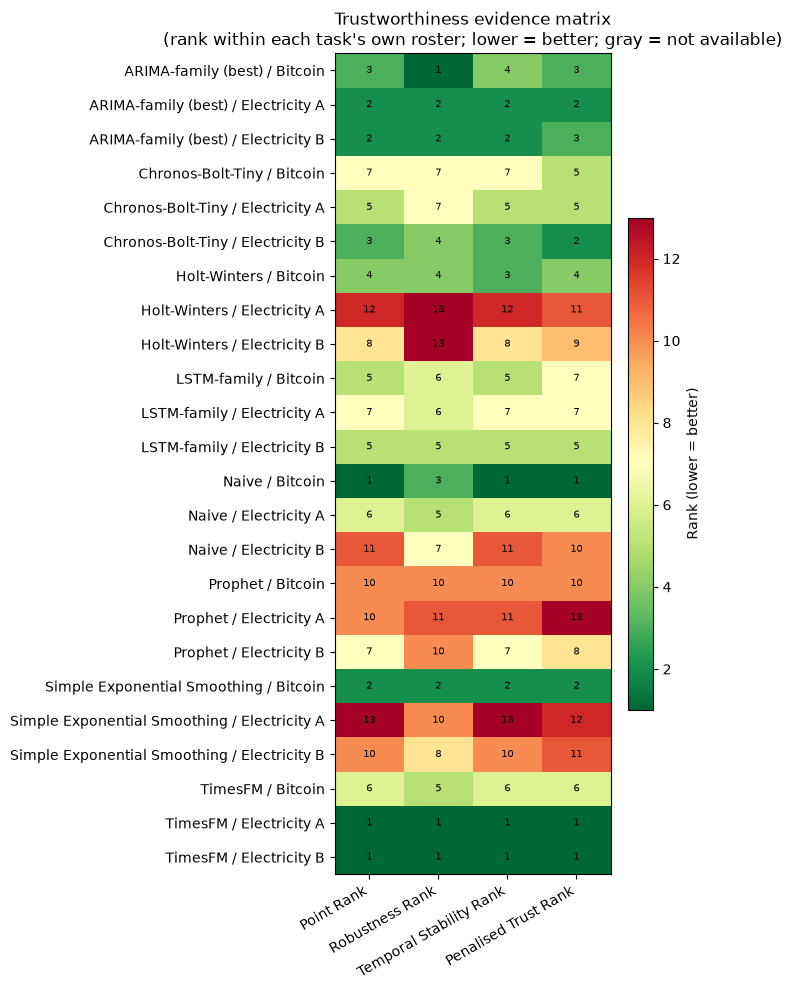

In [36]:
rank_cols = ["Point Rank", "Robustness Rank", "Temporal Stability Rank", "Penalised Trust Rank"]
heat_data = matrix[rank_cols].apply(pd.to_numeric).values.astype(float)
masked = np.ma.masked_invalid(heat_data)

fig, ax = plt.subplots(figsize=(7, 10))
cmap = plt.cm.RdYlGn_r.copy()
cmap.set_bad(color="0.9")
im = ax.imshow(masked, cmap=cmap, aspect="auto")
ax.set_xticks(range(len(rank_cols)), rank_cols, rotation=30, ha="right")
ax.set_yticks(range(len(matrix)), ["%s / %s" % (f, t) for f, t in matrix.index])
for i in range(masked.shape[0]):
    for j in range(masked.shape[1]):
        if not masked.mask[i, j]:
            ax.text(j, i, "%d" % masked[i, j], ha="center", va="center", fontsize=7)
        else:
            ax.text(j, i, "n/a", ha="center", va="center", fontsize=6, color="gray")
ax.set_title("Trustworthiness evidence matrix\n(rank within each task's own roster; lower = better; gray = not available)")
fig.colorbar(im, ax=ax, shrink=0.6, label="Rank (lower = better)")
plt.tight_layout()
plt.show()

# 11. Statistical Inference Across Tasks

Domain-specific inference methods are preserved exactly as computed upstream. No test is
recomputed here, and no p-value is pooled across domains.

## 11.1 Methodological Differences

In [37]:
def correction_label(df, holm_col, bh_col):
    if holm_col in df.columns:
        return "Holm (family-wise error control)"
    if bh_col in df.columns:
        return "Benjamini-Hochberg (false discovery rate control)"
    return "Unknown"

methodology = pd.DataFrame([
    {"Property": "Models", "Bitcoin": n_bitcoin_models, "Electricity A": n_electricity_a_models, "Electricity B": n_electricity_b_models},
    {"Property": "Pairwise comparisons", "Bitcoin": len(bitcoin_dm), "Electricity A": len(electricity_dm_a), "Electricity B": len(electricity_dm_b)},
    {"Property": "Primary loss", "Bitcoin": "Squared error (RMSE-based)", "Electricity A": electricity_dm_a.Loss.unique()[0], "Electricity B": electricity_dm_b.Loss.unique()[0]},
    {"Property": "HAC lag", "Bitcoin": int(bitcoin_dm["HAC Lag"].unique()[0]), "Electricity A": int(electricity_dm_a.HAC_Lag.unique()[0]), "Electricity B": int(electricity_dm_b.HAC_Lag.unique()[0])},
    {"Property": "Multiplicity correction", "Bitcoin": correction_label(bitcoin_dm, "Holm-adjusted p-value", "p_value_BH"),
     "Electricity A": correction_label(electricity_dm_a, "Holm-adjusted p-value", "p_value_BH"),
     "Electricity B": correction_label(electricity_dm_b, "Holm-adjusted p-value", "p_value_BH")},
    {"Property": "Inference unit", "Bitcoin": "Daily target", "Electricity A": "Half-hourly target", "Electricity B": "Daily origin (48-step vector)"},
]).set_index("Property")
display(methodology)

,Bitcoin,Electricity A,Electricity B
Property,,,
Models,10,13,13
Pairwise comparisons,45,78,78
Primary loss,Squared error (RMSE-based),Squared Error,Squared Error
HAC lag,6,48,7
Multiplicity correction,Holm (family-wise error control),Benjamini-Hochberg (false discovery rate control),Benjamini-Hochberg (false discovery rate control)
Inference unit,Daily target,Half-hourly target,Daily origin (48-step vector)


## 11.2 Focused Cross-Domain Evidence

In [38]:
def find_comparison(domain, protocol_substr, keyword_groups):
    sub = significance_cmp[(significance_cmp.Domain == domain) & (significance_cmp.Protocol.str.contains(protocol_substr))]
    for _, r in sub.iterrows():
        if all(any(kw.lower() in r.Comparison.lower() for kw in group) for group in keyword_groups):
            sig = "Significant" if r.Significant else "Not significant"
            return "%s (%s has lower loss)" % (sig, r.Lower_Loss_Model), r.Practical_Interpretation
    return "Not directly tested in this artifact", ""

focused_rows = []
scientific_comparisons = [
    ("TimesFM vs Chronos-Bolt-Tiny", [["timesfm"], ["chronos"]]),
    ("Foundation model vs strongest ARIMA-family baseline", [["timesfm"], ["arima", "sarima"]]),
    ("LSTM-family vs TimesFM", [["lstm"], ["timesfm"]]),
    ("Simple/seasonal baseline vs foundation model", [["naive"], ["timesfm", "chronos"]]),
]
for label, kw in scientific_comparisons:
    row = {"Scientific Comparison": label}
    for task, dom, proto in [("Bitcoin", "Bitcoin", ""), ("Electricity A", "Electricity", "A"), ("Electricity B", "Electricity", "B")]:
        cell, _ = find_comparison(dom, proto, kw)
        row[task] = cell
    focused_rows.append(row)
focused_table = pd.DataFrame(focused_rows).set_index("Scientific Comparison")
display(focused_table)

,Bitcoin,Electricity A,Electricity B
Scientific Comparison,,,
TimesFM vs Chronos-Bolt-Tiny,Not significant (TimesFM has lower loss),Significant (TimesFM has lower loss),Significant (TimesFM has lower loss)
Foundation model vs strongest ARIMA-family baseline,Significant (ARIMA Rolling One-Step has lower ...,Significant (SARIMA has lower loss),Significant (TimesFM has lower loss)
LSTM-family vs TimesFM,Not significant (Persistence-Enhanced Log-Retu...,Not directly tested in this artifact,Not directly tested in this artifact
Simple/seasonal baseline vs foundation model,Significant (Naive has lower loss),Significant (Chronos-Bolt-Tiny has lower loss),Significant (TimesFM has lower loss)


## 11.3 Effect Size Context

Effect-size definitions are not identical across domains (Bitcoin's practical-interpretation labels
come from its own RMSE-difference framework; Electricity's come from its own MASE-48-relative
framework), so magnitudes are reported qualitatively per task rather than forced into one numeric
scale.

In [39]:
effect_rows = []
for label, kw in scientific_comparisons:
    row = {"Scientific Comparison": label}
    for task, dom, proto in [("Bitcoin", "Bitcoin", ""), ("Electricity A", "Electricity", "A"), ("Electricity B", "Electricity", "B")]:
        _, interp = find_comparison(dom, proto, kw)
        row[task] = interp if interp else "Not directly tested"
    effect_rows.append(row)
display(pd.DataFrame(effect_rows).set_index("Scientific Comparison"))

,Bitcoin,Electricity A,Electricity B
Scientific Comparison,,,
TimesFM vs Chronos-Bolt-Tiny,TimesFM improves on Chronos but not on Naive.,TimesFM significantly beats Chronos.,TimesFM significantly beats Chronos.
Foundation model vs strongest ARIMA-family baseline,ARIMA-family comparison: TimesFM vs Bitcoin's ...,ARIMA-family comparison: TimesFM vs Electricit...,ARIMA-family comparison: TimesFM vs Electricit...
LSTM-family vs TimesFM,No statistically significant difference was de...,Not directly tested,Not directly tested
Simple/seasonal baseline vs foundation model,TimesFM does not beat persistence; Naive has l...,Chronos significantly beats Naive on squared l...,TimesFM significantly beats the strongest day-...


## 11.4 Important Methodological Note

The number of statistically significant pairs cannot be directly interpreted as a cross-domain
measure of model separability, because:

- sample sizes differ (1,061 daily targets vs 46,176 half-hourly targets vs 962 daily origins);
- loss dependence structure differs (daily autocorrelation vs half-hourly/daily seasonal autocorrelation);
- HAC lags differ (6 vs 48 vs 7), reflecting each series' own dependence length;
- multiplicity corrections differ (Holm's family-wise control vs Benjamini-Hochberg's false discovery rate control), which answer different statistical questions at different family sizes;
- the tasks themselves differ in target, frequency, and horizon.

A "significant" result in one domain and a "not significant" result in another are not directly
comparable claims of effect strength without accounting for all of the above.

# 12. Horizon and Information-Update Effects

Electricity Protocol A (rolling one-step) vs Protocol B (fixed-origin 48-step day-ahead) is the
controlled within-domain contrast for horizon and information-update discipline: the target,
frequency, and model roster are identical between the two, so a rank change here can be
attributed to horizon/update discipline in a way a Bitcoin-vs-Electricity comparison cannot,
since domain changes simultaneously with everything else in that comparison.

In [40]:
horizon_effect = rank_stability[["Model_Family", "Electricity_Protocol_A_Rank", "Electricity_Protocol_B_Rank"]].copy()
horizon_effect["Change (B - A)"] = horizon_effect.Electricity_Protocol_B_Rank - horizon_effect.Electricity_Protocol_A_Rank

def horizon_interp(change):
    if change > 0:
        return "Weakens at day-ahead"
    if change < 0:
        return "Strengthens at day-ahead"
    return "Stable across horizon"

horizon_effect["Interpretation"] = horizon_effect["Change (B - A)"].map(horizon_interp)
horizon_effect = horizon_effect.rename(columns={
    "Electricity_Protocol_A_Rank": "Electricity A Rank", "Electricity_Protocol_B_Rank": "Electricity B Rank"})
display(horizon_effect.sort_values("Change (B - A)"))

,Model_Family,Electricity A Rank,Electricity B Rank,Change (B - A),Interpretation
5,Holt-Winters,12,8,-4,Strengthens at day-ahead
6,Simple Exponential Smoothing,13,10,-3,Strengthens at day-ahead
7,Prophet,10,7,-3,Strengthens at day-ahead
3,LSTM-family,7,5,-2,Strengthens at day-ahead
2,Chronos-Bolt-Tiny,5,3,-2,Strengthens at day-ahead
1,TimesFM,1,1,0,Stable across horizon
0,ARIMA-family (best),2,2,0,Stable across horizon
4,Naive,6,11,5,Weakens at day-ahead


Within the ARIMA family, this table shows a sharp contrast: DHR-ARIMA-tuned-for-one-step
(Electricity's harmonic-regression variant) and plain ARIMA both weaken sharply at day-ahead,
while SARIMA (a sequential state extension) stays close to its one-step rank. Daily Seasonal
Naive strengthens at day-ahead relative to one-step, consistent with a fixed daily periodic
pattern mattering more at a 24-hour horizon than at a 30-minute one.

Bitcoin's own task is daily one-step, not directly on this A/B horizon axis. Comparing Bitcoin's
rank to Electricity's is therefore not a clean horizon experiment: domain, frequency, and horizon
all change together, so **Electricity A vs B isolates horizon/update discipline far more cleanly
than a Bitcoin-vs-Electricity comparison would**, and this notebook does not claim to separate
domain and horizon effects across the Bitcoin/Electricity boundary.

# 13. Cross-Domain Model Profiles

These profiles synthesize the tables already computed above; no new metric is introduced here.

## 13.1 TimesFM

In [41]:
tfm = rank_stability[rank_stability.Model_Family == "TimesFM"].iloc[0]
tfm_cov = native_view[native_view.Model == "TimesFM"].set_index("Task")["Absolute_Coverage_Error"]
display(Markdown(
    "- **Rank:** Bitcoin %d of %d; Electricity A %d of %d; Electricity B %d of %d.\n"
    "- **Baseline-relative:** %s\n"
    "- **Calibration:** absolute 80%% coverage error of %.3f (Bitcoin), %.3f (Electricity A), %.3f (Electricity B) -- the larger of the two foundation models' coverage errors in every task.\n"
    "- **Rank variability:** mean rank %.2f, rank std %.2f across the three tasks -- the widest spread of the two foundation models, driven by a strong Electricity rank offsetting a weak Bitcoin rank."
    % (
        int(tfm.Bitcoin_Rank), ROSTER_SIZE["Bitcoin"], int(tfm.Electricity_Protocol_A_Rank), ROSTER_SIZE["Electricity A"], int(tfm.Electricity_Protocol_B_Rank), ROSTER_SIZE["Electricity B"],
        "; ".join("%s/%s vs %s: beat baseline = %s" % (r.Domain, r.Protocol.split(":")[0], r.Strongest_Baseline, r.Beat_Baseline) for r in foundation[foundation.Model == "TimesFM"].itertuples()),
        tfm_cov.get("Bitcoin", np.nan), tfm_cov.get("Electricity A", np.nan), tfm_cov.get("Electricity B", np.nan),
        tfm.Mean_Rank, tfm.Rank_Std,
    )
))

- **Rank:** Bitcoin 6 of 10; Electricity A 1 of 13; Electricity B 1 of 13.
- **Baseline-relative:** Bitcoin/Rolling one-step daily vs Naive: beat baseline = False; Electricity/Protocol A vs SARIMA: beat baseline = True; Electricity/Protocol B vs SARIMA: beat baseline = True
- **Calibration:** absolute 80% coverage error of 0.469 (Bitcoin), 0.464 (Electricity A), 0.554 (Electricity B) -- the larger of the two foundation models' coverage errors in every task.
- **Rank variability:** mean rank 2.67, rank std 2.89 across the three tasks -- the widest spread of the two foundation models, driven by a strong Electricity rank offsetting a weak Bitcoin rank.

## 13.2 Chronos-Bolt-Tiny

In [42]:
chr_row = rank_stability[rank_stability.Model_Family == "Chronos-Bolt-Tiny"].iloc[0]
chr_cov = native_view[native_view.Model == "Chronos-Bolt-Tiny"].set_index("Task")["Absolute_Coverage_Error"]
display(Markdown(
    "- **Rank:** Bitcoin %d of %d; Electricity A %d of %d; Electricity B %d of %d.\n"
    "- **Calibration:** absolute 80%% coverage error of %.3f (Bitcoin), %.3f (Electricity A), %.3f (Electricity B) -- the smaller of the two foundation models' coverage errors in every task shown.\n"
    "- **Rank variability:** mean rank %.2f, rank std %.2f -- weaker point accuracy than TimesFM in Electricity, but a more consistent (if not leading) rank profile."
    % (
        int(chr_row.Bitcoin_Rank), ROSTER_SIZE["Bitcoin"], int(chr_row.Electricity_Protocol_A_Rank), ROSTER_SIZE["Electricity A"], int(chr_row.Electricity_Protocol_B_Rank), ROSTER_SIZE["Electricity B"],
        chr_cov.get("Bitcoin", np.nan), chr_cov.get("Electricity A", np.nan), chr_cov.get("Electricity B", np.nan),
        chr_row.Mean_Rank, chr_row.Rank_Std,
    )
))

- **Rank:** Bitcoin 7 of 10; Electricity A 5 of 13; Electricity B 3 of 13.
- **Calibration:** absolute 80% coverage error of 0.045 (Bitcoin), 0.111 (Electricity A), 0.124 (Electricity B) -- the smaller of the two foundation models' coverage errors in every task shown.
- **Rank variability:** mean rank 5.00, rank std 2.00 -- weaker point accuracy than TimesFM in Electricity, but a more consistent (if not leading) rank profile.

## 13.3 Classical / Statistical Systems

In [43]:
arima_row = rank_stability[rank_stability.Model_Family == "ARIMA-family (best)"].iloc[0]
naive_row = rank_stability[rank_stability.Model_Family == "Naive"].iloc[0]
display(Markdown(
    "- **Persistence (Naive):** Bitcoin rank %d of %d (the single best Bitcoin model by MAE, in a near-tie -- Section 5.3); Electricity A rank %d of %d; Electricity B rank %d of %d. Persistence is strong at short/no horizon but weakens sharply at Electricity's 48-step horizon.\n"
    "- **ARIMA-family (best-in-family):** mean rank %.2f, rank std %.2f across the three tasks -- the lowest rank variability of the 8 comparable families (Section 6.4), driven by SARIMA staying strong at both Electricity horizons and plain ARIMA being competitive in Bitcoin.\n"
    "- These are best-in-family/domain-adapted comparisons (Section 4), not identical-model comparisons: Bitcoin's ARIMA-family entry has no seasonal or harmonic-regression component, while Electricity's does."
    % (
        int(naive_row.Bitcoin_Rank), ROSTER_SIZE["Bitcoin"], int(naive_row.Electricity_Protocol_A_Rank), ROSTER_SIZE["Electricity A"], int(naive_row.Electricity_Protocol_B_Rank), ROSTER_SIZE["Electricity B"],
        arima_row.Mean_Rank, arima_row.Rank_Std,
    )
))

- **Persistence (Naive):** Bitcoin rank 1 of 10 (the single best Bitcoin model by MAE, in a near-tie -- Section 5.3); Electricity A rank 6 of 13; Electricity B rank 11 of 13. Persistence is strong at short/no horizon but weakens sharply at Electricity's 48-step horizon.
- **ARIMA-family (best-in-family):** mean rank 2.33, rank std 0.58 across the three tasks -- the lowest rank variability of the 8 comparable families (Section 6.4), driven by SARIMA staying strong at both Electricity horizons and plain ARIMA being competitive in Bitcoin.
- These are best-in-family/domain-adapted comparisons (Section 4), not identical-model comparisons: Bitcoin's ARIMA-family entry has no seasonal or harmonic-regression component, while Electricity's does.

## 13.4 Neural Models

In [44]:
lstm_row = rank_stability[rank_stability.Model_Family == "LSTM-family"].iloc[0]
display(Markdown(
    "- **LSTM-family:** Bitcoin rank %d of %d (persistence-enhanced log-return LSTM); Electricity A rank %d of %d; Electricity B rank %d of %d (direct-demand LSTM).\n"
    "- Mean rank %.2f, rank std %.2f. These are **not** the same architecture or target transform (Section 4.3) -- the comparison is at the level of 'a recurrent neural network was evaluated in this task', not a controlled architecture comparison.\n"
    "- Both domain-specific LSTMs sit in the middle of their respective rosters rather than leading or trailing them."
    % (
        int(lstm_row.Bitcoin_Rank), ROSTER_SIZE["Bitcoin"], int(lstm_row.Electricity_Protocol_A_Rank), ROSTER_SIZE["Electricity A"], int(lstm_row.Electricity_Protocol_B_Rank), ROSTER_SIZE["Electricity B"],
        lstm_row.Mean_Rank, lstm_row.Rank_Std,
    )
))

- **LSTM-family:** Bitcoin rank 5 of 10 (persistence-enhanced log-return LSTM); Electricity A rank 7 of 13; Electricity B rank 5 of 13 (direct-demand LSTM).
- Mean rank 5.67, rank std 1.15. These are **not** the same architecture or target transform (Section 4.3) -- the comparison is at the level of 'a recurrent neural network was evaluated in this task', not a controlled architecture comparison.
- Both domain-specific LSTMs sit in the middle of their respective rosters rather than leading or trailing them.

## 13.5 Deterministic Baselines

Simple deterministic baselines (Naive, moving averages, seasonal-naive variants) remain
scientifically important reference points in both domains: Bitcoin's Naive model is not merely
competitive but the single top-ranked model by MAE (Section 5.1), and Electricity's Daily Seasonal
Naive strengthens materially at the day-ahead horizon (Section 12). A model that cannot
convincingly beat these baselines has not demonstrated added forecasting value in that task,
regardless of its architectural sophistication.

# 14. Convergent Findings Across Completed Domains

Only findings supported by evidence in both completed domains/tasks are listed here. Each
statement below is checked against computed evidence before being written.

In [45]:
assert tfm.Bitcoin_Rank > 1, "TimesFM should not lead Bitcoin for this finding to hold"
assert tfm.Electricity_Protocol_A_Rank == 1 and tfm.Electricity_Protocol_B_Rank == 1
assert naive_row.Bitcoin_Rank == 1
assert (arima_row.Electricity_Protocol_A_Rank <= 2) and (arima_row.Electricity_Protocol_B_Rank <= 2)
chronos_better_calibrated = (chr_cov < tfm_cov).all()
assert chronos_better_calibrated
assert (horizon_effect["Change (B - A)"].abs() > 0).any()
weak_components = disagreement.set_index(["Task", "Model_Family"])["Largest Component Weakness"]
assert weak_components.nunique() > 1

display(Markdown(
    "**1. Foundation models are not universally dominant.** TimesFM ranks %d of %d in Bitcoin but "
    "1st of %d in both Electricity protocols -- point-accuracy leadership is task-specific, not a "
    "general property of the model.\n\n"
    "**2. Strong simple/statistical baselines remain essential.** Bitcoin's Naive model ranks 1st "
    "of %d by MAE (in a near-tie -- Section 5.3); Electricity's SARIMA ranks 2nd of %d in both "
    "protocols. Neither foundation model has decisively beaten the strongest baseline in every task.\n\n"
    "**3. Point accuracy does not determine calibration.** Chronos-Bolt-Tiny has the smaller "
    "absolute 80%% coverage error of the two foundation models in all three tasks (Section 9.4), "
    "despite trailing TimesFM's point rank in Electricity.\n\n"
    "**4. Model quality depends on operational protocol.** The Electricity A-vs-B horizon contrast "
    "(Section 12) changes multiple model-family ranks materially within the same domain, target, "
    "and roster -- protocol is not a neutral evaluation detail.\n\n"
    "**5. Trustworthiness is multidimensional.** The component-vs-composite view (Section 10.4) "
    "shows different models have different largest component weaknesses -- aggregate accuracy, "
    "robustness, Temporal Stability, uncertainty, and auditability do not always point to the same "
    "model preference."
    % (int(tfm.Bitcoin_Rank), ROSTER_SIZE["Bitcoin"], ROSTER_SIZE["Electricity A"],
       ROSTER_SIZE["Bitcoin"], ROSTER_SIZE["Electricity A"])
))

**1. Foundation models are not universally dominant.** TimesFM ranks 6 of 10 in Bitcoin but 1st of 13 in both Electricity protocols -- point-accuracy leadership is task-specific, not a general property of the model.

**2. Strong simple/statistical baselines remain essential.** Bitcoin's Naive model ranks 1st of 10 by MAE (in a near-tie -- Section 5.3); Electricity's SARIMA ranks 2nd of 13 in both protocols. Neither foundation model has decisively beaten the strongest baseline in every task.

**3. Point accuracy does not determine calibration.** Chronos-Bolt-Tiny has the smaller absolute 80% coverage error of the two foundation models in all three tasks (Section 9.4), despite trailing TimesFM's point rank in Electricity.

**4. Model quality depends on operational protocol.** The Electricity A-vs-B horizon contrast (Section 12) changes multiple model-family ranks materially within the same domain, target, and roster -- protocol is not a neutral evaluation detail.

**5. Trustworthiness is multidimensional.** The component-vs-composite view (Section 10.4) shows different models have different largest component weaknesses -- aggregate accuracy, robustness, Temporal Stability, uncertainty, and auditability do not always point to the same model preference.

# 15. Domain-Specific Findings

These findings are not presented as cross-domain general laws -- they are specific to one domain's
own data-generating process and evaluation protocol.

In [46]:
dhr_rank_a = int(comparison[(comparison.Domain == "Electricity") & (comparison.Protocol.str.contains("A")) & (comparison.Model == "DHR-ARIMA")].Within_Domain_Rank.iloc[0])
dhr_rank_b = int(comparison[(comparison.Domain == "Electricity") & (comparison.Protocol.str.contains("B")) & (comparison.Model == "DHR-ARIMA")].Within_Domain_Rank.iloc[0])

display(Markdown(
    "**Bitcoin-specific**\n\n"
    "- Persistence dominance: Naive and Simple Exponential Smoothing are within %.4f%% of each "
    "other in MAE and both outrank every other model (Section 5.3).\n"
    "- No exploitable daily/weekly seasonality was found in Bitcoin price returns (Section 4.1), "
    "so no seasonal-naive baseline exists for Bitcoin, unlike Electricity.\n"
    "- TimesFM and Chronos-Bolt-Tiny rank %d and %d of %d respectively, trailing five other models "
    "including plain ARIMA and additive-trend exponential smoothing.\n\n"
    "**Electricity-specific**\n\n"
    "- Strong daily/weekly seasonal structure supports dedicated seasonal-naive baselines with no "
    "Bitcoin equivalent.\n"
    "- Day-ahead horizon degradation is sharp for one-step-tuned ARIMA-family models: DHR-ARIMA "
    "moves from rank %d of %d (Protocol A) to rank %d of %d (Protocol B).\n"
    "- SARIMA is the strongest non-foundation baseline in both Electricity protocols, a role Naive "
    "does not play in Electricity the way it does in Bitcoin."
    % (
        bitcoin_margin_pct,
        int(tfm.Bitcoin_Rank), int(chr_row.Bitcoin_Rank), ROSTER_SIZE["Bitcoin"],
        dhr_rank_a, ROSTER_SIZE["Electricity A"], dhr_rank_b, ROSTER_SIZE["Electricity B"],
    )
))

**Bitcoin-specific**

- Persistence dominance: Naive and Simple Exponential Smoothing are within 0.7379% of each other in MAE and both outrank every other model (Section 5.3).
- No exploitable daily/weekly seasonality was found in Bitcoin price returns (Section 4.1), so no seasonal-naive baseline exists for Bitcoin, unlike Electricity.
- TimesFM and Chronos-Bolt-Tiny rank 6 and 7 of 10 respectively, trailing five other models including plain ARIMA and additive-trend exponential smoothing.

**Electricity-specific**

- Strong daily/weekly seasonal structure supports dedicated seasonal-naive baselines with no Bitcoin equivalent.
- Day-ahead horizon degradation is sharp for one-step-tuned ARIMA-family models: DHR-ARIMA moves from rank 3 of 13 (Protocol A) to rank 12 of 13 (Protocol B).
- SARIMA is the strongest non-foundation baseline in both Electricity protocols, a role Naive does not play in Electricity the way it does in Bitcoin.

# 16. Research Implications

The completed evidence connects back to the study's primary research question -- under what
domain, horizon, and information-update conditions zero-shot foundation models are trustworthy
relative to strong benchmarks -- in several concrete ways:

- **Benchmark design matters.** A comparison that only reports aggregate point accuracy on a
  single roster would have missed the calibration reversal (Section 9.4), the horizon reversal
  (Section 12), and the component-vs-composite disagreement (Section 10.4) documented above.
- **Update discipline is a first-class experimental variable**, not an implementation detail: the
  Electricity A-vs-B contrast changes conclusions about which classical model is "best" within the
  same domain and roster.
- **Calibration evidence should be evaluated separately from point accuracy**, since the two do not
  move together for either foundation model in this evidence base.
- **Evidence completeness should be tracked explicitly.** Section 10.2 shows that uncertainty
  evidence is unavailable for most non-foundation models in both domains -- a trustworthiness
  claim that ignores this gap would overstate what is known.
- **Frozen, hash-verified artifacts made this synthesis possible without recomputation**, and the
  same discipline (freeze, verify, then compare) is what would let a third completed domain be
  added without disturbing the first two.
- **Multidimensional evaluation changes model preference** in this evidence base: several models
  that lead on accuracy do not lead on every trustworthiness component (Section 10.4).

The current two-domain evidence **motivates** these implications; it does not **prove** they hold
generally. A claim that any of the above is a universal property of foundation-model forecasting
would require more than two domains, more than two zero-shot model families, and more than one
frozen evaluation period per domain -- which is precisely the gap Section 20 addresses.

# 17. Validation and Cross-Domain Evidence Integrity

In [47]:
audit_rows = []

def audit(category, check, expected, observed, status):
    audit_rows.append({"Category": category, "Check": check, "Expected": expected, "Observed": observed, "Status": status})

# --- Artifact Integrity ---
expected_files = [families, not_comparable, comparison, foundation, trust_cmp, uncertainty_cmp, significance_cmp, rank_stability]
audit("Artifact Integrity", "All 8 cross-domain CSVs load and are non-empty", "8 non-empty frames",
      "%d non-empty of 8" % sum(len(f) > 0 for f in expected_files),
      "PASS" if all(len(f) > 0 for f in expected_files) else "FAIL")

dup = comparison.duplicated(["Domain", "Protocol", "Model"]).sum()
audit("Artifact Integrity", "No duplicate Domain/Protocol/Model rows in comparison table", 0, int(dup), "PASS" if dup == 0 else "FAIL")

audit("Artifact Integrity", "Bitcoin model count matches bitcoin_trustworthiness_components_v2.csv",
      len(bitcoin_components), n_bitcoin_models, "PASS" if len(bitcoin_components) == n_bitcoin_models else "FAIL")
audit("Artifact Integrity", "Electricity A model count matches protocol_a_trust_scores.csv",
      len(electricity_trust_a), n_electricity_a_models, "PASS" if len(electricity_trust_a) == n_electricity_a_models else "FAIL")
audit("Artifact Integrity", "Electricity B model count matches protocol_b_trust_scores.csv",
      len(electricity_trust_b), n_electricity_b_models, "PASS" if len(electricity_trust_b) == n_electricity_b_models else "FAIL")

bitcoin_rank_by_mae = comparison[comparison.Domain == "Bitcoin"].sort_values("MAE").Model.tolist()
bitcoin_rank_by_col = comparison[comparison.Domain == "Bitcoin"].sort_values("Within_Domain_Rank").Model.tolist()
audit("Artifact Integrity", "Bitcoin Within_Domain_Rank column matches MAE ordering", "identical order",
      "identical" if bitcoin_rank_by_mae == bitcoin_rank_by_col else "MISMATCH",
      "PASS" if bitcoin_rank_by_mae == bitcoin_rank_by_col else "FAIL")

elec_a_rank_by_mase = comparison[(comparison.Domain == "Electricity") & (comparison.Protocol.str.contains("A"))].sort_values("MASE_48").Model.tolist()
elec_a_rank_by_col = comparison[(comparison.Domain == "Electricity") & (comparison.Protocol.str.contains("A"))].sort_values("Within_Domain_Rank").Model.tolist()
audit("Artifact Integrity", "Electricity A Within_Domain_Rank column matches MASE-48 ordering", "identical order",
      "identical" if elec_a_rank_by_mase == elec_a_rank_by_col else "MISMATCH",
      "PASS" if elec_a_rank_by_mase == elec_a_rank_by_col else "FAIL")

# --- Source Parity ---
bitcoin_naive_mae_source = float(bitcoin_point_metrics.set_index("Model").loc["Naive", "MAE"])
bitcoin_naive_mae_crossdomain = float(comparison[(comparison.Domain == "Bitcoin") & (comparison.Model == "Naive")].MAE.iloc[0])
audit("Source Parity", "Cross-domain Bitcoin Naive MAE reproduces bitcoin_point_forecast_metrics_v2.csv",
      round(bitcoin_naive_mae_source, 6), round(bitcoin_naive_mae_crossdomain, 6),
      "PASS" if abs(bitcoin_naive_mae_source - bitcoin_naive_mae_crossdomain) < 1e-6 else "FAIL")

elec_a_timesfm_mase_source = float(electricity_trust_a.set_index("Model").loc["TimesFM", "MASE_48"])
elec_a_timesfm_mase_crossdomain = float(comparison[(comparison.Domain == "Electricity") & (comparison.Protocol.str.contains("A")) & (comparison.Model == "TimesFM")].MASE_48.iloc[0])
audit("Source Parity", "Cross-domain Electricity A TimesFM MASE-48 reproduces protocol_a_trust_scores.csv",
      round(elec_a_timesfm_mase_source, 6), round(elec_a_timesfm_mase_crossdomain, 6),
      "PASS" if abs(elec_a_timesfm_mase_source - elec_a_timesfm_mase_crossdomain) < 1e-6 else "FAIL")

# --- Comparability Integrity ---
pooled_cols = [c for c in list(comparison.columns) + list(trust_cmp.columns) if "combined" in c.lower() or "pooled" in c.lower()]
audit("Comparability Integrity", "No pooled/combined cross-domain metric column exists", 0, len(pooled_cols),
      "PASS" if len(pooled_cols) == 0 else "FAIL")

protocols_distinct = set(comparison[comparison.Domain == "Electricity"].Protocol.unique())
audit("Comparability Integrity", "Protocol A and B remain distinct labels in comparison table", ">= 2 distinct labels",
      len(protocols_distinct), "PASS" if len(protocols_distinct) >= 2 else "FAIL")

roster_reproduced = (ROSTER_SIZE["Bitcoin"], ROSTER_SIZE["Electricity A"], ROSTER_SIZE["Electricity B"]) == (10, 13, 13)
audit("Comparability Integrity", "Normalized rank denominators equal current roster sizes", "(10, 13, 13)",
      (ROSTER_SIZE["Bitcoin"], ROSTER_SIZE["Electricity A"], ROSTER_SIZE["Electricity B"]),
      "PASS" if roster_reproduced else "NOT DIRECTLY COMPARABLE")

recomputed_rel = (baseline_relative.Model_MAE - baseline_relative.Baseline_MAE) / baseline_relative.Baseline_MAE * 100
rel_diff_ok = np.allclose(recomputed_rel.values, baseline_relative.Relative_MAE_Difference_Percent.values, atol=1e-6)
audit("Comparability Integrity", "Baseline-relative percentages recompute from Model/Baseline MAE", "match within 1e-6",
      "match" if rel_diff_ok else "MISMATCH", "PASS" if rel_diff_ok else "FAIL")

# --- Uncertainty Integrity ---
cal_types_ok = set(uncertainty_cmp.Calibration_Type) == {"Native", "Calibrated"}
audit("Uncertainty Integrity", "Native and calibrated evidence remain distinct rows", "{Native, Calibrated}",
      set(uncertainty_cmp.Calibration_Type), "PASS" if cal_types_ok else "FAIL")

nominal_ok = (uncertainty_cmp.Nominal_Coverage == 0.8).all()
audit("Uncertainty Integrity", "Nominal coverage level identified correctly as 80%", "all rows == 0.80",
      "all == 0.80" if nominal_ok else "mismatch found", "PASS" if nominal_ok else "FAIL")

elec_calibrated_empty = uncertainty_cmp[(uncertainty_cmp.Domain == "Electricity") & (uncertainty_cmp.Calibration_Type == "Calibrated")].empty
audit("Uncertainty Integrity", "Electricity has no fabricated post-hoc calibrated rows", "0 rows",
      "0 rows" if elec_calibrated_empty else "unexpected rows present", "PASS" if elec_calibrated_empty else "FAIL")

# --- Statistical Integrity ---
bitcoin_corr = methodology.loc["Multiplicity correction", "Bitcoin"]
elec_a_corr = methodology.loc["Multiplicity correction", "Electricity A"]
audit("Statistical Integrity", "Bitcoin uses Holm, Electricity uses Benjamini-Hochberg", "Holm / BH",
      "%s / %s" % (bitcoin_corr.split(" ")[0], elec_a_corr.split(" ")[0]),
      "PASS" if bitcoin_corr.startswith("Holm") and elec_a_corr.startswith("Benjamini") else "FAIL")

domains_in_sig = set(significance_cmp.Domain.unique())
audit("Statistical Integrity", "No pooled cross-domain hypothesis test row exists", "{Bitcoin, Electricity}",
      domains_in_sig, "PASS" if domains_in_sig == {"Bitcoin", "Electricity"} else "FAIL")

pair_counts_ok = (len(bitcoin_dm) == int(methodology.loc["Pairwise comparisons", "Bitcoin"])
                   and len(electricity_dm_a) == int(methodology.loc["Pairwise comparisons", "Electricity A"])
                   and len(electricity_dm_b) == int(methodology.loc["Pairwise comparisons", "Electricity B"]))
audit("Statistical Integrity", "Pair counts in methodology table match source DM artifacts", "45 / 78 / 78",
      "%d / %d / %d" % (len(bitcoin_dm), len(electricity_dm_a), len(electricity_dm_b)), "PASS" if pair_counts_ok else "FAIL")

# --- Trustworthiness Integrity ---
source_col_intact = "Relative_Generalisation_Score" in trust_cmp.columns
audit("Trustworthiness Integrity", "Temporal Stability display alias does not rename source column", "column present",
      "present" if source_col_intact else "renamed/missing", "PASS" if source_col_intact else "FAIL")

variants_distinct = not composite.Penalised_Trust_Score.equals(composite.Evidence_Available_Trust_Score)
audit("Trustworthiness Integrity", "Missing-evidence-penalised and evidence-available composites remain separate columns",
      "distinct series", "distinct" if variants_distinct else "identical", "PASS" if variants_distinct else "FAIL")

used_normalized = "Normalized Penalised Rank" in composite.columns
audit("Trustworthiness Integrity", "Cross-task composite comparison uses normalized rank, not raw magnitude",
      "normalized-rank column present", "present" if used_normalized else "absent", "PASS" if used_normalized else "FAIL")

audit_table = pd.DataFrame(audit_rows)
display(audit_table)
status_counts = audit_table.Status.value_counts()
display(status_counts)
assert (audit_table.Status == "FAIL").sum() == 0, "One or more validation checks failed"

,Category,Check,Expected,Observed,Status
0,Artifact Integrity,All 8 cross-domain CSVs load and are non-empty,8 non-empty frames,8 non-empty of 8,PASS
1,Artifact Integrity,No duplicate Domain/Protocol/Model rows in com...,0,0,PASS
2,Artifact Integrity,Bitcoin model count matches bitcoin_trustworth...,10,10,PASS
3,Artifact Integrity,Electricity A model count matches protocol_a_t...,13,13,PASS
4,Artifact Integrity,Electricity B model count matches protocol_b_t...,13,13,PASS
5,Artifact Integrity,Bitcoin Within_Domain_Rank column matches MAE ...,identical order,identical,PASS
6,Artifact Integrity,Electricity A Within_Domain_Rank column matche...,identical order,identical,PASS
7,Source Parity,Cross-domain Bitcoin Naive MAE reproduces bitc...,1290.353242,1290.353242,PASS
8,Source Parity,Cross-domain Electricity A TimesFM MASE-48 rep...,0.140002,0.140002,PASS
9,Comparability Integrity,No pooled/combined cross-domain metric column ...,0,0,PASS


Status
PASS    22
Name: count, dtype: int64

# 18. Key Findings

In [48]:
timesfm_beats_all = "; ".join(
    "%s: %s" % (r.Domain if r.Domain == "Bitcoin" else ("Electricity " + r.Protocol.split(":")[0].strip()[-1]), r.Beat_Baseline)
    for r in foundation[foundation.Model == "TimesFM"].itertuples()
)
robustness_note = "aggregate accuracy and robustness rank match for most, but not all, comparable families" \
    if (pd.concat([acc_vs_rob_bitcoin, acc_vs_rob_a, acc_vs_rob_b]).Difference.abs() > 2).any() else \
    "aggregate accuracy and robustness rank are closely aligned across comparable families"

display(Markdown(
    "**Foundation model ranking.** TimesFM ranks %d of %d in Bitcoin, and 1st of %d in both "
    "Electricity protocols; Chronos-Bolt-Tiny ranks %d of %d in Bitcoin, %d of %d in Electricity A, "
    "%d of %d in Electricity B.\n\n"
    "**Baseline-relative performance.** %s.\n\n"
    "**Rank stability.** %s shows the largest normalized-rank movement across the three tasks "
    "(range %.3f); %s is the most stable comparable family (range %.3f).\n\n"
    "**Calibration.** Chronos-Bolt-Tiny has the smaller absolute 80%% coverage error than TimesFM "
    "in all three tasks (Section 9.4); TimesFM's point-accuracy lead in Electricity comes with "
    "materially worse native calibration.\n\n"
    "**Robustness / Temporal Stability.** %s (Section 7.3, Section 8.2).\n\n"
    "**Statistical evidence.** TimesFM significantly beats Chronos-Bolt-Tiny on squared loss in "
    "both Electricity protocols; in Electricity A, SARIMA has significantly lower squared loss than "
    "TimesFM despite TimesFM's lower MAE (Section 11.2) -- a metric-dependent foundation-model lead, "
    "not an absolute one.\n\n"
    "**Horizon dependence.** DHR-ARIMA falls from rank %d of %d (Protocol A) to rank %d of %d "
    "(Protocol B); SARIMA and Daily Seasonal Naive are comparatively stable or strengthen at the "
    "day-ahead horizon (Section 12).\n\n"
    "**Overall interpretation.**\n\n"
    "> The completed evidence supports domain- and protocol-dependent model superiority, not a "
    "universal forecasting hierarchy."
    % (
        int(tfm.Bitcoin_Rank), ROSTER_SIZE["Bitcoin"], ROSTER_SIZE["Electricity A"],
        int(chr_row.Bitcoin_Rank), ROSTER_SIZE["Bitcoin"], int(chr_row.Electricity_Protocol_A_Rank), ROSTER_SIZE["Electricity A"], int(chr_row.Electricity_Protocol_B_Rank), ROSTER_SIZE["Electricity B"],
        timesfm_beats_all,
        movers.iloc[0].Model_Family, movers.iloc[0]["Normalized Rank Range"], movers.iloc[-1].Model_Family, movers.iloc[-1]["Normalized Rank Range"],
        robustness_note,
        dhr_rank_a, ROSTER_SIZE["Electricity A"], dhr_rank_b, ROSTER_SIZE["Electricity B"],
    )
))

**Foundation model ranking.** TimesFM ranks 6 of 10 in Bitcoin, and 1st of 13 in both Electricity protocols; Chronos-Bolt-Tiny ranks 7 of 10 in Bitcoin, 5 of 13 in Electricity A, 3 of 13 in Electricity B.

**Baseline-relative performance.** Bitcoin: False; Electricity A: True; Electricity B: True.

**Rank stability.** Simple Exponential Smoothing shows the largest normalized-rank movement across the three tasks (range 0.889); ARIMA-family (best) is the most stable comparable family (range 0.139).

**Calibration.** Chronos-Bolt-Tiny has the smaller absolute 80% coverage error than TimesFM in all three tasks (Section 9.4); TimesFM's point-accuracy lead in Electricity comes with materially worse native calibration.

**Robustness / Temporal Stability.** aggregate accuracy and robustness rank match for most, but not all, comparable families (Section 7.3, Section 8.2).

**Statistical evidence.** TimesFM significantly beats Chronos-Bolt-Tiny on squared loss in both Electricity protocols; in Electricity A, SARIMA has significantly lower squared loss than TimesFM despite TimesFM's lower MAE (Section 11.2) -- a metric-dependent foundation-model lead, not an absolute one.

**Horizon dependence.** DHR-ARIMA falls from rank 3 of 13 (Protocol A) to rank 12 of 13 (Protocol B); SARIMA and Daily Seasonal Naive are comparatively stable or strengthen at the day-ahead horizon (Section 12).

**Overall interpretation.**

> The completed evidence supports domain- and protocol-dependent model superiority, not a universal forecasting hierarchy.

# 19. Limitations

In [49]:
display(Markdown(
    "**Only two completed domains.** %d Bitcoin models and %d Electricity models per protocol "
    "(%d in Protocol A, %d in Protocol B) are evaluated; Finance and Energy cannot establish "
    "universal cross-domain generalisation on their own.\n\n"
    "**Different frequencies and horizons.** Bitcoin's daily one-step task and Electricity's "
    "30-minute one-step / 48-step day-ahead tasks differ substantially in frequency, horizon, and "
    "the operational meaning of a forecast error.\n\n"
    "**Model-family rather than exact-architecture matching.** LSTM and ARIMA-family comparisons "
    "(Section 4) use domain-adapted representatives, not identical architectures -- rank "
    "comparisons for those families are model-class comparisons, not model-for-model ones.\n\n"
    "**Comparison-set-relative scores.** Robustness, Temporal Stability, and Trust Scores (Sections "
    "7-10) are normalized against each task's own roster; a numerically identical score in a "
    "%d-model roster and a %d-model roster is not the same competitive claim.\n\n"
    "**Different statistical corrections.** Bitcoin's Holm family-wise control and Electricity's "
    "Benjamini-Hochberg false discovery rate control (Section 11) answer different questions at "
    "different family sizes and are never pooled.\n\n"
    "**Limited probabilistic evidence.** Only Chronos-Bolt-Tiny and TimesFM have native uncertainty "
    "evidence in both domains; %d of %d comparable-family models have no uncertainty score at all "
    "(Section 10.2), and only one nominal interval level (80%%) is evaluated.\n\n"
    "**Potential pretraining overlap.** Whether either foundation model's pretraining corpus "
    "overlapped with the evaluated Bitcoin or Electricity test periods is unresolved.\n\n"
    "**Single Bitcoin asset.** BTC/USD only; no other cryptocurrency or traditional financial asset "
    "is evaluated.\n\n"
    "**Single Electricity region.** South Australia only; no other grid region is evaluated.\n\n"
    "**No causal attribution.** Rank changes between Bitcoin and Electricity cannot be causally "
    "assigned to domain or horizon alone, since domain, frequency, horizon, and update discipline "
    "all change simultaneously between them; only the Electricity A-vs-B contrast (Section 12) "
    "isolates horizon/update discipline with a controlled design.\n\n"
    "**Future domains incomplete.** Weather and Transport remain proposed work (Section 20) and "
    "contribute no results to this notebook."
    % (
        n_bitcoin_models, ROSTER_SIZE["Electricity A"], n_electricity_a_models, n_electricity_b_models,
        ROSTER_SIZE["Bitcoin"], ROSTER_SIZE["Electricity A"],
        int(avail_table.apply(lambda r: (r != "None").sum(), axis=1).sum()), len(avail_table) * 3,
    )
))

**Only two completed domains.** 10 Bitcoin models and 13 Electricity models per protocol (13 in Protocol A, 13 in Protocol B) are evaluated; Finance and Energy cannot establish universal cross-domain generalisation on their own.

**Different frequencies and horizons.** Bitcoin's daily one-step task and Electricity's 30-minute one-step / 48-step day-ahead tasks differ substantially in frequency, horizon, and the operational meaning of a forecast error.

**Model-family rather than exact-architecture matching.** LSTM and ARIMA-family comparisons (Section 4) use domain-adapted representatives, not identical architectures -- rank comparisons for those families are model-class comparisons, not model-for-model ones.

**Comparison-set-relative scores.** Robustness, Temporal Stability, and Trust Scores (Sections 7-10) are normalized against each task's own roster; a numerically identical score in a 10-model roster and a 13-model roster is not the same competitive claim.

**Different statistical corrections.** Bitcoin's Holm family-wise control and Electricity's Benjamini-Hochberg false discovery rate control (Section 11) answer different questions at different family sizes and are never pooled.

**Limited probabilistic evidence.** Only Chronos-Bolt-Tiny and TimesFM have native uncertainty evidence in both domains; 12 of 24 comparable-family models have no uncertainty score at all (Section 10.2), and only one nominal interval level (80%) is evaluated.

**Potential pretraining overlap.** Whether either foundation model's pretraining corpus overlapped with the evaluated Bitcoin or Electricity test periods is unresolved.

**Single Bitcoin asset.** BTC/USD only; no other cryptocurrency or traditional financial asset is evaluated.

**Single Electricity region.** South Australia only; no other grid region is evaluated.

**No causal attribution.** Rank changes between Bitcoin and Electricity cannot be causally assigned to domain or horizon alone, since domain, frequency, horizon, and update discipline all change simultaneously between them; only the Electricity A-vs-B contrast (Section 12) isolates horizon/update discipline with a controlled design.

**Future domains incomplete.** Weather and Transport remain proposed work (Section 20) and contribute no results to this notebook.

# 20. Future-Domain Handoff

Weather and Transport are the repository's two planned extensions. Neither contributes results to
this notebook. For either to plug into this cross-domain framework on the same terms as Bitcoin and
Electricity, its own domain notebooks should freeze, before any cross-domain comparison is written:

- a chronological train/validation/test split, with the split boundary fixed before model fitting;
- the task/horizon definition (single-step, multi-step, or both, matching this repository's
  rolling-one-step vs fixed-origin distinction where relevant);
- the information-update rule (whether the actual value becomes available before the next forecast
  origin);
- the strongest protocol-eligible non-foundation baseline for that domain;
- zero-shot foundation-model forecasts under the same protocol as the domain's other models;
- regime definitions for Regime-Conditional Robustness, defined from training-only information;
- contiguous Earlier/Middle/Later segments for Temporal Stability;
- uncertainty evidence (native coverage at minimum; calibrated evidence where feasible), with
  missing evidence recorded as missing rather than imputed;
- Diebold-Mariano or an equivalent dependence-aware pairwise inference artifact, with an explicit
  HAC lag and multiplicity-correction choice suited to that domain's own pair count; and
- an artifact verifier / hash ledger entry, so the new domain's evidence is auditable the same way
  Bitcoin's and Electricity's already are.

Once frozen, the new domain would extend this notebook's comparisons using **normalized within-task
rank**, **baseline-relative change**, **calibration error at a matching nominal level**, and
**component-level trust evidence** -- the same comparison primitives used throughout Sections 5-11,
never raw cross-domain error magnitudes and never pooled p-values.

This notebook does **not** prescribe that a third domain's results must match the convergent
findings in Section 14. A third domain that contradicts them would be a legitimate and useful
scientific result in its own right.